# Benchmark: Reproducing SI WIMP limits from XENONnT, LZ, and PandaX-4T

In [1]:
import os
import diamx
from diamx.model import DiamxModel
from diamx.utils import generate_bin_array
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch

diamx_dir = os.path.dirname(diamx.__file__)

import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="appletree.config")
warnings.filterwarnings("ignore", category=UserWarning, module="appletree.component")

XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform


/home/mhliu/Documents/private_nt_aux_files/ntauxfiles/interface.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Using aptext package from https://github.com/XENONnT/applefiles


Some plot styles...

In [2]:
plt.style.use("seaborn-v0_8-colorblind")
plt.rcParams.update(
    {
        "figure.figsize": (6.4, 4.8),
        "figure.dpi": 600,
        "font.family": "serif",
        "font.size": 12,
        # 'figure.dpi': 300,
        "lines.linewidth": 2.0,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "xtick.major.size": 8,
        "xtick.minor.size": 4,
        "ytick.major.size": 8,
        "ytick.minor.size": 4,
        "xtick.major.width": 1,
        "xtick.minor.width": 0.7,
        "ytick.major.width": 1,
        "ytick.minor.width": 0.7,
        "xtick.direction": "in",
        "ytick.direction": "in",
        # 'legend.loc': 'upper center',
        # 'legend.bbox_to_anchor': (0.5, 1.05),
        # 'legend.ncol': 3,
        "legend.fancybox": True,  # if True, use a rounded box for the
        # legend background, else a rectangle
        "legend.fontsize": 12,
    }
)

## 0. Generate Input WIMP spectrum

Using package wimprates

In [ ]:
import wimprates

energies = np.linspace(0.01, 100, 200)
wimp_masses = (
    list(range(6, 130, 2)) + list(range(130, 400, 10)) + [400, 500, 600, 800, 1000]
)
wimp_masses += list(range(100, 1000, 50)) + [1000, 2500, 5000, 10000]
wimp_masses = set(wimp_masses)
spectrum_data = np.zeros((len(energies), 2))
spectrum_data[:, 0] = energies
os.makedirs("./diamx_output/spectrum", exist_ok=True)
for wimp_mass in wimp_masses:
    spectrum_csv_fpath = os.path.join(
        "./diamx_output", "spectrum", f"wimp_{wimp_mass}GeV.csv"
    )
    spectrum_data[:, 1] = wimprates.rate_wimp_std(
        energies, mw=wimp_mass, sigma_nucleon=1e-44
    )
    np.savetxt(spectrum_csv_fpath, spectrum_data, delimiter=",")

In [3]:
def plot_contours_and_pies(context, plot_config, file_base="../diamx/data"):
    """
    Plots the contours for the given plot configuration.

    Parameters
    ----------
    context : DiamxModel
        The Diamx model context.
    plot_config : dict
        The plot configuration dictionary containing the experiment name and specifications for each plot item.
        It should have the following structure:
        {
            "experiment_name": "experiment_name",
            "signal_parameter_value": 1000, # For the best_fit model
            "content_specs": [
                # For each component to plot
                {
                    "type": "bkg", # or "shaped_bkg" or "best_fit_bkg" or "signal"
                    "plot_contour_diamx": "contour", # or "contourf" or False
                    "plot_contour_literature": True, # or False
                    "include_in_pie_charts": True,
                    "component_name": "background_name",
                    "shape_parameter_value": 0.5, # Only for shaped_bkg
                    "color": "blue",
                    "one_sigma_contour_fname": "one_sigma_contour.csv",
                    "two_sigma_contour_fname": "two_sigma_contour.csv",
                    "log10_contour": True,
                    "label": "Label for the plot item"
                },
                ...
            ],
            "fig_specs": {
                "figure_size": [4, 3],
                "axis_names": ["cs1", "cs2"],
                "axis_labels": ["cS1 [PE]", "cS2 [PE]"],
                "axis_limits": [[0, 100], [10**2.1, 10**4.1]],
                "axis_scales": ["linear", "log"],
                "contour_linestyles": ["--", "-"],
                "plot_pie_charts": True,
                "pie_size_min": 2,
                "pie_size_max": 10,
                "pie_axis_width": 0.01,
                "pie_axis_height": 0.01,
                "legend_kwargs": {
                    "loc": "upper center",
                    "bbox_to_anchor": (0.5, 1.05),
                    "ncol": 3,
                }
            },
        }
    file_base : str
        The base directory where the contour files are located.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The matplotlib figure object.
    ax : matplotlib.axes.Axes
        The matplotlib axes object.
    """
    fig_specs = plot_config.get(
        "fig_specs",
        {
            "figure_size": [4, 3],
            "axis_names": ["cs1", "cs2"],
            "axis_labels": ["cS1 [PE]", "cS2 [PE]"],
            "axis_limits": [[0, 100], [10**2.1, 10**4.1]],
            "axis_scales": ["linear", "log"],
            "contour_linestyles": ["--", "-"],
            "plot_pie_charts": True,
            "pie_size_min": 2,
            "pie_size_max": 10,
            "pie_axis_width": 0.01,
            "pie_axis_height": 0.01,
        },
    )
    fig, ax = plt.subplots(1, 1, figsize=fig_specs.get("figure_size", [4, 3]))
    ax.set_xlabel(fig_specs["axis_labels"][0])
    ax.set_ylabel(fig_specs["axis_labels"][1])
    ax.set_xscale(fig_specs["axis_scales"][0])
    ax.set_xlim(fig_specs["axis_limits"][0])
    ax.set_yscale(fig_specs["axis_scales"][1])
    ax.set_ylim(fig_specs["axis_limits"][1])
    experiment_name = plot_config["experiment_name"]
    for plot_item in plot_config["content_specs"]:
        plot_mode_diamx = plot_item.get("plot_contour_diamx", "contour")
        if plot_mode_diamx is not False:
            if plot_item["type"] == "bkg":
                if plot_mode_diamx == "contour":
                    context.plot_bkg_template(
                        experiment_name,
                        plot_item["component_name"],
                        mode=["contour"],
                        contour_kwargs={
                            "colors": [plot_item["color"], plot_item["color"]],
                            "linestyles": fig_specs.get(
                                "contour_linestyles", ["--", "-"]
                            ),
                        },
                    )
                elif plot_mode_diamx == "contourf":
                    context.plot_bkg_template(
                        experiment_name,
                        plot_item["component_name"],
                        mode=["contourf"],
                        contourf_kwargs={
                            "colors": [plot_item["color"], plot_item["color"]],
                            "alpha": fig_specs.get("contourf_alpha", [0.1, 0.2]),
                            "extend": "max",
                        },
                    )
            elif plot_item["type"] == "shaped_bkg":
                assert (
                    "shape_parameter_value" in plot_item
                ), "shape_parameter_value must be provided for shaped_bkg"
                if plot_mode_diamx == "contour":
                    context.plot_bkg_template(
                        experiment_name,
                        plot_item["component_name"],
                        shape_parameter_value=plot_item["shape_parameter_value"],
                        mode=["contour"],
                        contour_kwargs={
                            "colors": [plot_item["color"], plot_item["color"]],
                            "linestyles": fig_specs.get(
                                "contour_linestyles", ["--", "-"]
                            ),
                        },
                    )
                elif plot_mode_diamx == "contourf":
                    context.plot_bkg_template(
                        experiment_name,
                        plot_item["component_name"],
                        shape_parameter_value=plot_item["shape_parameter_value"],
                        mode=["contourf"],
                        contourf_kwargs={
                            "colors": [plot_item["color"], plot_item["color"]],
                            "alpha": fig_specs.get("contourf_alpha", [0.1, 0.2]),
                            "extend": "max",
                        },
                    )
            elif plot_item["type"] == "best_fit_bkg":
                if plot_mode_diamx == "contour":
                    context.plot_best_fit_bkg_mh(
                        experiment_name,
                        plot_config["signal_parameter_value"],
                        bkg_to_include=plot_item.get("bkg_to_include", None),
                        mode=["contour"],
                        contour_kwargs={
                            "colors": [plot_item["color"], plot_item["color"]],
                            "linestyles": fig_specs.get(
                                "contour_linestyles", ["--", "-"]
                            ),
                        },
                    )
                elif plot_mode_diamx == "contourf":
                    context.plot_best_fit_bkg_mh(
                        experiment_name,
                        plot_config["signal_parameter_value"],
                        bkg_to_include=plot_item.get("bkg_to_include", None),
                        mode=["contourf"],
                        contourf_kwargs={
                            "colors": [plot_item["color"], plot_item["color"]],
                            "alpha": fig_specs.get("contourf_alpha", [0.1, 0.2]),
                            "extend": "max",
                        },
                    )
            elif plot_item["type"] == "signal":
                context.plot_signal_template(
                    experiment_name,
                    plot_config["signal_parameter_value"],
                    mode=["contour"],
                    contour_kwargs={
                        "colors": [plot_item["color"], plot_item["color"]],
                        "linestyles": ["--", "-"],
                    },
                )
            else:
                raise ValueError(f"Unknown plot item type: {plot_item['type']}")
        if plot_item.get("plot_contour_literature", True):
            if "one_sigma_contour_fname" in plot_item:
                if isinstance(plot_item["one_sigma_contour_fname"], str):
                    one_sigma_fnames = [plot_item["one_sigma_contour_fname"]]
                else:
                    one_sigma_fnames = plot_item["one_sigma_contour_fname"]
                for one_sigma_fname in one_sigma_fnames:
                    one_sigma_contour = np.loadtxt(
                        os.path.join(file_base, one_sigma_fname), delimiter=","
                    )
                    if plot_item.get("log10_contour", False):
                        ax.fill(
                            one_sigma_contour[:, 0],
                            10 ** one_sigma_contour[:, 1],
                            color=plot_item["color"],
                            alpha=0.2,
                        )
                    else:
                        ax.fill(
                            one_sigma_contour[:, 0],
                            one_sigma_contour[:, 1],
                            color=plot_item["color"],
                            alpha=0.2,
                        )
            if "two_sigma_contour_fname" in plot_item:
                if isinstance(plot_item["two_sigma_contour_fname"], str):
                    two_sigma_fnames = [plot_item["two_sigma_contour_fname"]]
                else:
                    two_sigma_fnames = plot_item["two_sigma_contour_fname"]
                for two_sigma_fname in two_sigma_fnames:
                    two_sigma_contour = np.loadtxt(
                        os.path.join(file_base, two_sigma_fname), delimiter=","
                    )
                    if plot_item.get("log10_contour", False):
                        ax.fill(
                            two_sigma_contour[:, 0],
                            10 ** two_sigma_contour[:, 1],
                            color=plot_item["color"],
                            alpha=0.1,
                        )
                    else:
                        ax.fill(
                            two_sigma_contour[:, 0],
                            two_sigma_contour[:, 1],
                            color=plot_item["color"],
                            alpha=0.1,
                        )
    fig.canvas.draw()  # Render the figure to get the correct transforms
    data_to_figure = ax.transData + fig.transFigure.inverted()

    if fig_specs.get("plot_pie_charts", True):
        data = None
        for experiment_instance in context.experiment_instances:
            if experiment_instance.experiment_name == experiment_name:
                data = experiment_instance.get_data()
                break
        if data is None:
            raise ValueError(f"No data found for experiment {experiment_name}")
        local_pdf_raw = context.get_best_fit_local_pdf(
            experiment_name=experiment_name,
            signal_parameter_value=plot_config["signal_parameter_value"],
            data_points=np.stack(
                (data[fig_specs["axis_names"][0]], data[fig_specs["axis_names"][1]]),
                axis=-1,
            ),
        )
        local_pdf_merged = (
            {}
        )  # Sometimes we need to merge multiple bkg into one in the pie chart
        component_color_map = {}
        best_fit_bkg_component_name = None
        signal_name = None
        for plot_item in plot_config["content_specs"]:
            if not plot_item.get("include_in_pie_charts", True):
                continue
            component_name = plot_item["component_name"]
            component_color_map[component_name] = plot_item["color"]
            if plot_item["type"] in ["bkg", "shaped_bkg"]:
                local_pdf_merged[component_name] = local_pdf_raw[component_name]
            elif plot_item["type"] == "best_fit_bkg":
                if "bkg_to_include" not in plot_item:
                    # If bkg_to_include is not given, we need to sum up all backgrounds except signal
                    # We will treat this case outside this loop
                    assert (
                        best_fit_bkg_component_name is None
                    ), "Only one best_fit_bkg without bkg_to_include is allowed"
                    best_fit_bkg_component_name = component_name
                    continue
                for bkg_name in plot_item["bkg_to_include"]:
                    if component_name in local_pdf_merged:
                        local_pdf_merged[component_name] += local_pdf_raw[bkg_name]
                    else:
                        local_pdf_merged[component_name] = local_pdf_raw[bkg_name]
            elif plot_item["type"] == "signal":
                local_pdf_merged[component_name] = local_pdf_raw[component_name]
                signal_name = component_name
        assert (
            signal_name is not None
        ), "Signal component must be included in the plot_config to draw pie charts"
        # Handle the case where best_fit_bkg includes all backgrounds except signal
        if best_fit_bkg_component_name is not None:
            total_bkg = np.zeros(len(data))
            for key in local_pdf_raw:
                if key != signal_name:
                    total_bkg += local_pdf_raw[key]
            local_pdf_merged[best_fit_bkg_component_name] = total_bkg

        data_points_pie_dtype = [
            (fig_specs["axis_names"][0], float),
            (fig_specs["axis_names"][1], float),
        ]
        for key in local_pdf_merged:
            data_points_pie_dtype.append((f"pdf_{key}", float))
        data_points_pie_dtype.append(("pie_size", float))
        data_points_pie = np.zeros(data.shape, dtype=data_points_pie_dtype)
        data_points_pie[fig_specs["axis_names"][0]] = data[fig_specs["axis_names"][0]]
        data_points_pie[fig_specs["axis_names"][1]] = data[fig_specs["axis_names"][1]]
        for key in local_pdf_merged:
            data_points_pie[f"pdf_{key}"] = local_pdf_merged[key]

        # Determine pie sizes based on signal component
        denom = np.add.reduce([local_pdf_merged[key] for key in local_pdf_merged])
        signal_relative_size = np.divide(
            local_pdf_merged[signal_name],
            denom,
            out=np.zeros_like(denom),
            where=denom > 0,
        )  # Avoid division by zero if the local pdf is all zero
        m = signal_relative_size.max()
        if m > 0:
            signal_relative_size = signal_relative_size / m
            data_points_pie["pie_size"] = fig_specs[
                "pie_size_min"
            ] + signal_relative_size * (
                fig_specs["pie_size_max"] - fig_specs["pie_size_min"]
            )
        else:
            data_points_pie["pie_size"] = fig_specs["pie_size_min"]

        # Order the pie charts by pie size (smallest drawn last)
        data_points_pie = np.sort(data_points_pie, order="pie_size")[::-1]

        for data_point_pie in data_points_pie:
            pie_center = data_to_figure.transform(
                (
                    data_point_pie[fig_specs["axis_names"][0]],
                    data_point_pie[fig_specs["axis_names"][1]],
                )
            )
            ax_pie = fig.add_axes(
                [
                    pie_center[0] - fig_specs["pie_axis_width"] / 2,
                    pie_center[1] - fig_specs["pie_axis_height"] / 2,
                    fig_specs["pie_axis_width"],
                    fig_specs["pie_axis_height"],
                ]
            )
            ax_pie.pie(
                [data_point_pie[f"pdf_{key}"] for key in local_pdf_merged],
                colors=[component_color_map[key] for key in local_pdf_merged],
                radius=data_point_pie["pie_size"],
            )

    legend_handles = [
        Patch(facecolor=plot_item["color"], alpha=1, label=plot_item["label"])
        for plot_item in plot_config["content_specs"]
    ]
    ax.legend(handles=legend_handles, **fig_specs.get("legend_kwargs", {}))
    return fig, ax

## 1. XENONnT SR0

In [ ]:
xenonnt_sr0_st = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "xenonnt_sr0_wimp_config_full_roi.json"),
)
xenonnt_sr0_st.register_experiment(diamx.experiments.XENONnTSR0)
xenonnt_sr0_st.generate_templates()

In [ ]:
fig, ax = plot_contours_and_pies(
    xenonnt_sr0_st,
    {
        "experiment_name": "xenonnt_sr0",
        "signal_parameter_value": 200,
        "content_specs": [
            {
                "type": "bkg",
                "plot_contour_diamx": "contour",
                "plot_contour_literature": True,
                "component_name": "er",
                "color": "blue",
                "one_sigma_contour_fname": "xenonnt_sr0_er_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr0_er_2sigma.csv",
                "log10_contour": False,
                "label": "ER",
            },
            {
                "type": "bkg",
                "plot_contour_diamx": "contour",
                "plot_contour_literature": True,
                "component_name": "neutron",
                "color": "orange",
                "two_sigma_contour_fname": "xenonnt_sr0_neutron_2sigma.csv",
                "log10_contour": False,
                "label": "Neutron",
            },
            {
                "type": "bkg",
                "plot_contour_diamx": False,
                "plot_contour_literature": True,
                "component_name": "ac",
                "color": "purple",
                "one_sigma_contour_fname": "xenonnt_sr0_ac_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr0_ac_2sigma.csv",
                "log10_contour": False,
                "label": "AC",
            },
            {
                "type": "bkg",
                "plot_contour_diamx": False,
                "plot_contour_literature": True,
                "component_name": "surface",
                "color": "green",
                "one_sigma_contour_fname": "xenonnt_sr0_surface_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr0_surface_2sigma.csv",
                "log10_contour": False,
                "label": "Surface",
            },
            {
                "type": "signal",
                "plot_contour_diamx": False,
                "plot_contour_literature": False,
                "component_name": "wimp",
                "color": "red",
                "label": "WIMP",
            },
        ],
        "fig_specs": {
            "figure_size": [6.4, 4.8],
            "axis_names": ["cs1", "cs2"],
            "axis_labels": ["cS1 [PE]", "cS2 [PE]"],
            "axis_limits": [[0, 100], [10**2.1, 10**4.1]],
            "axis_scales": ["linear", "log"],
            "contour_linestyles": ["--", "-"],
            "plot_pie_charts": True,
            "pie_size_min": 1,
            "pie_size_max": 6,
            "pie_axis_width": 0.01,
            "pie_axis_height": 0.01,
            "legend_kwargs": {
                "loc": "upper center",
                "bbox_to_anchor": (0.5, 1.17),
                "ncol": 3,
            },
        },
    },
)
ax.axhline(400, color="black", alpha=0.8, linestyle="--")
plt.savefig("../plots/xenonnt_sr0_cs1_cs2_contours.png", dpi=600, bbox_inches="tight")

In [7]:
xenonnt_sr0_st.print_best_fit(200)

True
xenonnt_sr0
           Nominal   Best fit
er             134   135 ± 12
neutron  1.1 ± 0.5  1.1 ± 0.5
ac       4.3 ± 0.9  4.3 ± 0.8
surface     14 ± 3     12 ± 2
Signal best fit: 1.6225777732678972



In [8]:
# For a more accurate estimation of parameter uncertainties:
model = xenonnt_sr0_st.get_alea_model(200)
model.fit()
model.minuit_object.minos()

True


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1267                       │              Nfcn = 633              │
│ EDM = 2.17e-06 (Goal: 0.0001)    │            time = 0.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬─────────────────────────────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name                                │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼─────────────────────────────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ wimp_rate_multiplier                │  0.0022   │  0.0042   │  -0.0022   │   0.0050   │    0    │  3000   │       │
│ 1 │ mass                                │    200    │     2     │            │            │         │         │  yes  │
│ 2 │ xenonnt_sr0_livetime                │  0.2605   │  0.0026   │            │            │         │         │  yes  │
│ 3 │ xenonnt_sr0_er_rate_multiplier      │   1.01    │   0.09    │   -0.09    │    0.09    │    0    │         │       │
│ 4 │ xenonnt_sr0_neutron_rate_multiplier │    1.0    │    0.5    │    -0.5    │    0.5     │    0    │         │       │
│ 5 │ xenonnt_sr0_ac_rate_multiplier      │    1.0    │    0.2    │    -0.2    │    0.2     │    0    │         │       │
│ 6 │ xenonnt_sr0_surface_rate_multiplier │   0.85    │   0.17    │   -0.17    │    0.18    │    0    │         │       │
│ 7 │ xenonnt_sr0_signal_efficiency       │   1.00    │   0.05    │   -0.05    │    0.05    │   0.5   │   1.5   │       │
└───┴─────────────────────────────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │ wimp_rate_multiplier  │xenonnt_sr0_er_rate_multiplier│xenonnt_sr0_neutron_rate_multiplier│xenonnt_sr0_ac_rate_multiplier│xenonnt_sr0_surface_rate_multiplier│xenonnt_sr0_signal_efficiency│
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.0022  │  0.0050   │   -0.09   │   0.09    │   -0.5    │    0.5    │   -0.2    │    0.2    │   -0.17   │   0.18    │   -0.05   │   0.05    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [ ]:
# Reproducing Fig. 4 (upper limit)
# xenonnt_sr0_st.run_inference(output_file_name="xenonnt_sr0_wimp_ci_full_roi.csv")
diamx.run_inference_pool(
    xenonnt_sr0_st,
    output_file_name="xenonnt_sr0_wimp_ci_full_roi.csv",
    processes=8,
)
ci = np.loadtxt("./diamx_output/xenonnt_sr0_wimp_ci_full_roi.csv", delimiter=",")
plt.plot(ci[:, 0], ci[:, 2] * 1e-44, label="diamx")
plt.yscale("log")
plt.xscale("log")
ci_literature = np.loadtxt("../diamx/data/xenonnt_sr0_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("XENONnT SR0 WIMP 90% CI")
plt.savefig("../plots/xenonnt_sr0_wimp_ci_full_roi.png", dpi=600)

Alternatively, use `cS2 > 400PE`:

In [3]:
xenonnt_sr0_st_400PE = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "xenonnt_sr0_wimp_config.json"),
)
xenonnt_sr0_st_400PE.register_experiment(diamx.experiments.XENONnTSR0)
xenonnt_sr0_st_400PE.generate_templates()
xenonnt_sr0_st_400PE.print_best_fit(200)

Generating background templates for xenonnt_sr0: 100%|██████████| 4/4 [00:00<00:00, 1348.98it/s]
Generating shaped background templates for xenonnt_sr0: 0it [00:00, ?it/s]
Generating signal templates for xenonnt_sr0: 100%|██████████| 90/90 [00:00<00:00, 1826.50it/s]


True
xenonnt_sr0
           Nominal   Best fit
er             134   134 ± 12
neutron  1.1 ± 0.5  1.1 ± 0.5
ac               1  0.0 ± 0.7
surface          1  3.0 ± 1.7
Signal best fit: 3.164179930384791



In [4]:
alea_model_400PE = xenonnt_sr0_st_400PE.get_alea_model(200)
alea_model_400PE.fit()
alea_model_400PE.minuit_object.minos()

True


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1184                       │              Nfcn = 780              │
│ EDM = 1.22e-05 (Goal: 0.0001)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬─────────────────────────────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name                                │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼─────────────────────────────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ wimp_rate_multiplier                │   0.004   │   0.005   │   -0.004   │   0.006    │    0    │  3000   │       │
│ 1 │ mass                                │    200    │     2     │            │            │         │         │  yes  │
│ 2 │ xenonnt_sr0_livetime                │  0.2605   │  0.0026   │            │            │         │         │  yes  │
│ 3 │ xenonnt_sr0_er_rate_multiplier      │   1.00    │   0.09    │   -0.09    │    0.09    │    0    │         │       │
│ 4 │ xenonnt_sr0_neutron_rate_multiplier │    1.0    │    0.5    │    -0.5    │    0.5     │    0    │         │       │
│ 5 │ xenonnt_sr0_ac_rate_multiplier      │  0.24e-6  │718799.11e-6│  -0.23e-6  │965699.59e-6│    0    │         │       │
│ 6 │ xenonnt_sr0_surface_rate_multiplier │    3.0    │    1.7    │    -1.4    │    2.1     │    0    │         │       │
│ 7 │ xenonnt_sr0_signal_efficiency       │   1.00    │   0.05    │   -0.05    │    0.05    │   0.5   │   1.5   │       │
└───┴─────────────────────────────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │ wimp_rate_multiplier  │xenonnt_sr0_er_rate_multiplier│xenonnt_sr0_neutron_rate_multiplier│xenonnt_sr0_ac_rate_multiplier│xenonnt_sr0_surface_rate_multiplier│xenonnt_sr0_signal_efficiency│
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.004   │   0.006   │   -0.09   │   0.09    │   -0.5    │    0.5    │ -0.23e-6  │965699.59e-6│   -1.4    │    2.1    │   -0.05   │   0.05    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   True    │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

In [ ]:
# xenonnt_sr0_st_400PE.run_inference(output_file_name="xenonnt_sr0_wimp_ci_400PE.csv")
diamx.run_inference_pool(
    xenonnt_sr0_st_400PE,
    output_file_name="xenonnt_sr0_wimp_ci_400PE.csv",
    processes=8,
)
ci_400PE = np.loadtxt("./diamx_output/xenonnt_sr0_wimp_ci_400PE.csv", delimiter=",")
plt.plot(ci_400PE[:, 0], ci_400PE[:, 2] * 1e-44, label="diamx (cS2 < 400PE)")
ci_literature = np.loadtxt("../diamx/data/xenonnt_sr0_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("XENONnT SR0 WIMP 90% CI")
plt.savefig("../plots/xenonnt_sr0_wimp_ci_400PE.png", dpi=600, bbox_inches="tight")

## 2. LZ WS2022

In [ ]:
lz_ws2022_st = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "lz_ws2022_wimp_config.json"),
)
lz_ws2022_st.register_experiment(diamx.experiments.LZWS2022)
# lz_ws2022_st.prepare()
lz_ws2022_st.generate_templates()

In [ ]:
plot_contours_and_pies(
    lz_ws2022_st,
    {
        "experiment_name": "lz_ws2022",
        "signal_parameter_value": 30,
        "content_specs": [
            {
                "type": "best_fit_bkg",
                "component_name": "er",
                "plot_contour_diamx": "contour",
                "plot_contour_literature": True,
                "color": "mediumblue",
                "one_sigma_contour_fname": "lz_ws2022_bkg_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2022_bkg_2sigma.csv",
                "log10_contour": True,
                "bkg_to_include": [
                    "beta",
                    "neutrino",
                    "xe127",
                    "xe124",
                    "xe136",
                    "ar37",
                ],
                "label": "ER",
            },
            {
                "type": "bkg",
                "component_name": "ar37",
                "plot_contour_diamx": "contour",
                "plot_contour_literature": True,
                "include_in_pie_charts": False,
                "color": "green",
                "one_sigma_contour_fname": "lz_ws2022_ar37_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2022_ar37_2sigma.csv",
                "log10_contour": True,
                "label": "Ar37",
            },
            {
                "type": "signal",
                "component_name": "wimp",
                "plot_contour_diamx": "contour",
                "plot_contour_literature": True,
                "color": "red",
                "one_sigma_contour_fname": "lz_ws2022_wimp_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2022_wimp_2sigma.csv",
                "log10_contour": True,
                "label": "WIMP",
            },
        ],
        "fig_specs": {
            "figure_size": [6.4, 4.8],
            "axis_names": ["s1c", "s2c"],
            "axis_labels": ["S1c [phd]", "S2c [phd]"],
            "axis_limits": [[3, 80], [600, 10**4.5]],
            "axis_scales": ["linear", "log"],
            "contour_linestyles": ["--", "-"],
            "plot_pie_charts": True,
            "pie_size_min": 1,
            "pie_size_max": 1,
            "pie_axis_width": 0.01,
            "pie_axis_height": 0.01,
            "legend_kwargs": {
                "loc": "upper center",
                "bbox_to_anchor": (0.5, 1.1),
                "ncol": 3,
            },
        },
    },
)

plt.savefig("../plots/lz_ws2022_s1c_s2c_contours.png", dpi=600, bbox_inches="tight")

In [13]:
lz_ws2022_st.print_best_fit(30, disable_rounding=True, stabilize_fit=False)

True
lz_ws2022
                           Nominal                                 Best fit
beta                  215.0 ± 36.0  223.96491535603718 ± 16.169763457608962
neutrino                27.1 ± 1.6   27.11838691279395 ± 1.5984846828021946
xe127                    9.2 ± 0.8   9.263876047153692 ± 0.7931419607130025
xe124     5.0 ± 1.3999999999999997   5.322142846393244 ± 1.3765318410698246
xe136                   15.1 ± 2.4   15.162610792510895 ± 2.389411149628825
ar37                          50.0     50.48584296372327 ± 9.08578730862105
Signal best fit: 5.66448843555421e-06



In [14]:
model = lz_ws2022_st.get_alea_model(30)
model.fit()
model.minuit_object.minos()

True


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2820                       │             Nfcn = 1053              │
│ EDM = 8.57e-06 (Goal: 0.0001)    │            time = 0.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬────────────────────────────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name                               │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼────────────────────────────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ wimp_rate_multiplier               │   4e-9    │ 463449e-9 │   -4e-9    │ 463058e-9  │    0    │  3000   │       │
│ 1 │ mass                               │   30.0    │    0.3    │            │            │         │         │  yes  │
│ 2 │ lz_ws2022_livetime                 │  0.1644   │  0.0016   │            │            │         │         │  yes  │
│ 3 │ lz_ws2022_beta_rate_multiplier     │   1.04    │   0.08    │   -0.07    │    0.08    │    0    │         │       │
│ 4 │ lz_ws2022_neutrino_rate_multiplier │   1.00    │   0.06    │   -0.06    │    0.06    │    0    │         │       │
│ 5 │ lz_ws2022_xe127_rate_multiplier    │   1.01    │   0.09    │   -0.09    │    0.09    │    0    │         │       │
│ 6 │ lz_ws2022_xe124_rate_multiplier    │   1.06    │   0.28    │   -0.28    │    0.28    │    0    │         │       │
│ 7 │ lz_ws2022_xe136_rate_multiplier    │   1.00    │   0.16    │   -0.16    │    0.16    │    0    │         │       │
│ 8 │ lz_ws2022_ar37_rate_multiplier     │   1.01    │   0.18    │   -0.18    │    0.19    │    0    │  5.76   │       │
│ 9 │ lz_ws2022_signal_efficiency        │   1.000   │   0.025   │   -0.025   │   0.025    │   0.5   │   1.5   │       │
└───┴────────────────────────────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │ wimp_rate_multiplier  │lz_ws2022_beta_rate_multiplier│lz_ws2022_neutrino_rate_multiplier│lz_ws2022_xe127_rate_multiplier│lz_ws2022_xe124_rate_multiplier│lz_ws2022_xe136_rate_multiplier│lz_ws2022_ar37_rate_multiplier│lz_ws2022_signal_efficiency│
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -4e-9   │ 463058e-9 │   -0.07   │   0.08    │   -0.06   │   0.06    │   -0.09   │   0.09    │   -0.28   │   0.28    │   -0.16   │   0.16    │   -0.18   │   0.19    │  -0.025   │   0.025   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   

In [ ]:
# Reproducing Fig. 5 (upper limit)
# lz_ws2022_st.run_inference(output_file_name="lz_ws2022_wimp_ci.csv")
diamx.run_inference_pool(
    lz_ws2022_st,
    output_file_name="lz_ws2022_wimp_ci.csv",
    processes=8,
)
ci = np.loadtxt("./diamx_output/lz_ws2022_wimp_ci.csv", delimiter=",")
plt.plot(ci[:, 0], ci[:, 2] * 1e-44, label="diamx")
plt.yscale("log")
plt.xscale("log")
ci_literature = np.loadtxt("../diamx/data/lz_ws2022_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("LZ WS2022 WIMP 90% CI")
plt.savefig("../plots/lz_ws2022_wimp_ci.png", dpi=600)

## 3. XENONnT combined SR0 & SR1

ROI: cS2 > 400PE

In [ ]:
xenonnt_sr01_st = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "xenonnt_sr0_and_1_wimp_config.json"),
)
xenonnt_sr01_st.register_experiment(diamx.experiments.XENONnTSR0)
xenonnt_sr01_st.register_experiment(diamx.experiments.XENONnTSR1a)
xenonnt_sr01_st.register_experiment(diamx.experiments.XENONnTSR1b)
# xenonnt_sr01_st.prepare()
xenonnt_sr01_st.generate_templates()

In [ ]:
plot_contours_and_pies(
    xenonnt_sr01_st,
    {
        "experiment_name": "xenonnt_sr1a",
        "signal_parameter_value": 200,
        "content_specs": [
            {
                "type": "best_fit_bkg",
                "component_name": "er",
                "plot_contour_diamx": "contour",
                "plot_contour_literature": True,
                "bkg_to_include": ["er_flat", "tritium", "ar37"],
                "color": "blue",
                "one_sigma_contour_fname": "xenonnt_sr1a_er_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1a_er_2sigma.csv",
                "log10_contour": False,
                "label": "ER",
            },
            {
                "type": "signal",
                "component_name": "wimp",
                "plot_contour_diamx": "contour",
                "plot_contour_literature": True,
                "color": "red",
                "one_sigma_contour_fname": "xenonnt_sr1b_wimp_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_wimp_2sigma.csv",
                "log10_contour": False,
                "label": "WIMP",
            },
            {
                "type": "bkg",
                "component_name": "xenonnt_sr1_ac",
                "plot_contour_diamx": False,
                "plot_contour_literature": True,
                "color": "purple",
                "one_sigma_contour_fname": "xenonnt_sr1b_ac_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_ac_2sigma.csv",
                "log10_contour": False,
                "label": "AC",
            },
        ],
        "fig_specs": {
            "figure_size": [6.4, 4.8],
            "axis_names": ["cs1", "cs2"],
            "axis_labels": ["cS1 [PE]", "cS2 [PE]"],
            "axis_limits": [[0, 100], [10**2.1, 10**4.1]],
            "axis_scales": ["linear", "log"],
            "contour_linestyles": ["--", "-"],
            "plot_pie_charts": True,
            "pie_size_min": 1,
            "pie_size_max": 6,
            "pie_axis_width": 0.01,
            "pie_axis_height": 0.01,
            "legend_kwargs": {
                "loc": "upper center",
                "bbox_to_anchor": (0.5, 1.1),
                "ncol": 4,
            },
        },
    },
)
plt.axhline(400, color="k", linestyle="--", alpha=0.2)
plt.savefig("../plots/xenonnt_sr1a_cs1_cs2_contours.png", dpi=600, bbox_inches="tight")

In [ ]:
plot_contours_and_pies(
    xenonnt_sr01_st,
    {
        "experiment_name": "xenonnt_sr1b",
        "signal_parameter_value": 200,
        "content_specs": [
            {
                "type": "best_fit_bkg",
                "plot_contour_diamx": "contour",
                "plot_contour_literature": True,
                "component_name": "er",
                "bkg_to_include": ["er_flat", "tritium"],
                "color": "blue",
                "one_sigma_contour_fname": "xenonnt_sr1b_er_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_er_2sigma.csv",
                "log10_contour": False,
                "label": "ER",
            },
            {
                "type": "signal",
                "plot_contour_diamx": "contour",
                "plot_contour_literature": True,
                "component_name": "wimp",
                "color": "red",
                "one_sigma_contour_fname": "xenonnt_sr1b_wimp_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_wimp_2sigma.csv",
                "log10_contour": False,
                "label": "WIMP",
            },
            {
                "type": "bkg",
                "plot_contour_diamx": False,
                "plot_contour_literature": True,
                "component_name": "xenonnt_sr1_ac",
                "color": "purple",
                "one_sigma_contour_fname": "xenonnt_sr1b_ac_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_ac_2sigma.csv",
                "log10_contour": False,
                "label": "AC",
            },
        ],
        "fig_specs": {
            "figure_size": [6.4, 4.8],
            "axis_names": ["cs1", "cs2"],
            "axis_labels": ["cS1 [PE]", "cS2 [PE]"],
            "axis_limits": [[0, 100], [10**2.1, 10**4.1]],
            "axis_scales": ["linear", "log"],
            "contour_linestyles": ["--", "-"],
            "plot_pie_charts": True,
            "pie_size_min": 1,
            "pie_size_max": 6,
            "pie_axis_width": 0.01,
            "pie_axis_height": 0.01,
            "legend_kwargs": {
                "loc": "upper center",
                "bbox_to_anchor": (0.5, 1.1),
                "ncol": 4,
            },
        },
    },
)

plt.axhline(400, color="k", linestyle="--", alpha=0.2)
plt.savefig("../plots/xenonnt_sr1b_cs1_cs2_contours.png", dpi=600, bbox_inches="tight")

In [20]:
xenonnt_sr01_st.print_best_fit(200)

True
True
True
xenonnt_sr0
                   Nominal   Best fit
er                     134   135 ± 12
xenonnt_neutron  0.7 ± 0.3  0.7 ± 0.3
ac                       1  0.0 ± 0.7
surface                  1  3.0 ± 1.7
Signal best fit: 1.8175673023721037

xenonnt_sr1a
                     Nominal     Best fit
er_flat             430 ± 30     460 ± 30
tritium                   62      20 ± 30
ar37                  58 ± 6       53 ± 5
xenonnt_neutron  0.47 ± 0.19  0.47 ± 0.19
xenonnt_sr1_ac   2.12 ± 0.18  2.11 ± 0.18
Signal best fit: 1.2180578724785507

xenonnt_sr1b
                   Nominal   Best fit
er_flat           151 ± 11   157 ± 10
tritium                101    69 ± 17
xenonnt_neutron  0.7 ± 0.3  0.7 ± 0.3
xenonnt_sr1_ac   3.8 ± 0.3  3.8 ± 0.3
Signal best fit: 2.19286995360628



In [21]:
model = xenonnt_sr01_st.get_alea_model(200)
model.fit()
model.minuit_object.minos()

True
True
True


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6707                       │             Nfcn = 3277              │
│ EDM = 1.76e-06 (Goal: 0.0001)    │            time = 2.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────────────────────────────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name                                 │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────────────────────────────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ wimp_rate_multiplier                 │  0.0025   │  0.0026   │  -0.0023   │   0.0029   │    0    │  3000   │       │
│ 1 │ mass                                 │    200    │     2     │            │            │         │         │  yes  │
│ 2 │ xenonnt_sr0_livetime                 │  0.2605   │  0.0026   │            │            │         │         │  yes  │
│ 3 │ xenonnt_sr0_er_rate_multiplier       │   1.01    │   0.09    │   -0.09    │    0.09    │    0    │         │       │
│ 4 │ xenonnt_neutron_rate_multiplier      │    1.0    │    0.4    │    -0.4    │    0.4     │    0    │         │       │
│ 5 │ xenonnt_sr0_ac_rate_multiplier       │ 0.031e-6  │748802.589e-6│ -0.032e-6  │1012862.140e-6│    0    │         │       │
│ 6 │ xenonnt_sr0_surface_rate_multiplier  │    3.0    │    1.7    │    -1.4    │    2.1     │    0    │         │       │
│ 7 │ xenonnt_sr0_signal_efficiency        │   1.00    │   0.05    │   -0.05    │    0.05    │   0.5   │   1.5   │       │
│ 8 │ xenonnt_sr1a_livetime                │  0.1825   │  0.0018   │            │            │         │         │  yes  │
│ 9 │ xenonnt_sr1a_er_flat_rate_multiplier │   1.06    │   0.06    │   -0.06    │    0.06    │    0    │         │       │
│ 10│ xenonnt_sr1a_tritium_rate_multiplier │   0.35    │   0.48    │   -0.35    │    0.53    │    0    │         │       │
│ 11│ xenonnt_sr1a_ar37_rate_multiplier    │   0.91    │   0.09    │   -0.09    │    0.09    │    0    │         │       │
│ 12│ xenonnt_sr1_ac_rate_multiplier       │   1.00    │   0.08    │   -0.08    │    0.08    │    0    │         │       │
│ 13│ xenonnt_sr1a_signal_efficiency       │   1.00    │   0.04    │   -0.04    │    0.04    │   0.5   │   1.5   │       │
│ 14│ xenonnt_sr1b_livetime                │  0.3285   │  0.0033   │            │            │         │         │  yes  │
│ 15│ xenonnt_sr1b_er_flat_rate_multiplier │   1.04    │   0.07    │   -0.07    │    0.07    │    0    │         │       │
│ 16│ xenonnt_sr1b_tritium_rate_multiplier │   0.69    │   0.17    │   -0.17    │    0.18    │    0    │         │       │
│ 17│ xenonnt_sr1b_signal_efficiency       │   1.00    │   0.04    │   -0.04    │    0.04    │   0.5   │   1.5   │       │
└───┴──────────────────────────────────────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │ wimp_rate_multip

In [ ]:
# xenonnt_sr01_st.run_inference(output_file_name="xenonnt_sr1_wimp_ci_full_roi.csv")
diamx.run_inference_pool(
    xenonnt_sr01_st,
    output_file_name="xenonnt_sr1_wimp_ci.csv",
    processes=8,
)
ci = np.loadtxt("./diamx_output/xenonnt_sr1_wimp_ci.csv", delimiter=",")
plt.plot(ci[:, 0], ci[:, 2] * 1e-44, label="diamx")
ci_literature = np.loadtxt("../diamx/data/xenonnt_sr1_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("XENONnT SR0&1 WIMP 90% CI")
plt.savefig("../plots/xenonnt_sr1_wimp_ci.png", dpi=600)
# plt.show()

Alternatively, introducing two floating parameters for Xe124 DEC charge yield:

In [ ]:
xenonnt_sr01_dec_st = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "xenonnt_sr0_and_1_wimp_config_dec.json"),
)
xenonnt_sr01_dec_st.register_experiment(diamx.experiments.XENONnTSR0)
xenonnt_sr01_dec_st.register_experiment(diamx.experiments.XENONnTSR1a)
xenonnt_sr01_dec_st.register_experiment(diamx.experiments.XENONnTSR1b)
# xenonnt_sr01_dec_st.prepare()
xenonnt_sr01_dec_st.generate_templates()

In [ ]:
diamx.run_inference_pool(
    xenonnt_sr01_dec_st,
    processes=10,
    output_file_name="xenonnt_sr01_dec_wimp_ci.csv",
    maxtasksperchild=1,
)

In [ ]:
ci_dec = np.loadtxt("./diamx_output/xenonnt_sr01_dec_wimp_ci.csv", delimiter=",")
plt.plot(ci_dec[:, 0], ci_dec[:, 2] * 1e-44, label="diamx (free DEC)")
ci_literature = np.loadtxt("../diamx/data/xenonnt_sr1_dec_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm$^2$]")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.savefig("../plots/xenonnt_sr1_dec_wimp_ci.png", dpi=600, bbox_inches="tight")

In [ ]:
plot_contours_and_pies(
    xenonnt_sr01_dec_st,
    {
        "experiment_name": "xenonnt_sr1b",
        "signal_parameter_value": 200,
        "content_specs": [
            {
                "type": "best_fit_bkg",
                "plot_contour_diamx": True,
                "plot_contour_literature": True,
                "component_name": "er",
                "bkg_to_include": ["er_flat", "tritium"],
                "color": "blue",
                "one_sigma_contour_fname": "xenonnt_sr1b_er_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_er_2sigma.csv",
                "log10_contour": False,
                "label": "ER",
            },
            {
                "type": "signal",
                "plot_contour_diamx": True,
                "plot_contour_literature": True,
                "component_name": "wimp",
                "color": "red",
                "one_sigma_contour_fname": "xenonnt_sr1b_wimp_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_wimp_2sigma.csv",
                "log10_contour": False,
                "label": "WIMP",
            },
            {
                "type": "bkg",
                "plot_contour_diamx": False,
                "plot_contour_literature": True,
                "component_name": "xenonnt_sr1_ac",
                "color": "purple",
                "one_sigma_contour_fname": "xenonnt_sr1b_ac_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_ac_2sigma.csv",
                "log10_contour": False,
                "label": "AC",
            },
            {
                "type": "best_fit_bkg",
                "plot_contour_diamx": True,
                "plot_contour_literature": False,
                "component_name": "xenonnt_sr1_xe124",
                "bkg_to_include": ["xenonnt_sr1_xe124"],
                "color": "indigo",
                "label": "Xe124",
            },
        ],
        "fig_specs": {
            "figure_size": [6.4, 4.8],
            "axis_names": ["cs1", "cs2"],
            "axis_labels": ["cS1 [PE]", "cS2 [PE]"],
            "axis_limits": [[0, 100], [10**2.1, 10**4.1]],
            "axis_scales": ["linear", "log"],
            "contour_linestyles": ["--", "-"],
            "plot_pie_charts": True,
            "pie_size_min": 1,
            "pie_size_max": 6,
            "pie_axis_width": 0.01,
            "pie_axis_height": 0.01,
            "legend_kwargs": {
                "loc": "upper center",
                "bbox_to_anchor": (0.5, 1.1),
                "ncol": 4,
            },
        },
    },
)

In [ ]:
plot_contours_and_pies(
    xenonnt_sr01_dec_st,
    {
        "experiment_name": "xenonnt_sr1b",
        "signal_parameter_value": 200,
        "content_specs": [
            {
                "type": "best_fit_bkg",
                "plot_contour_diamx": True,
                "plot_contour_literature": True,
                "component_name": "er",
                "bkg_to_include": ["er_flat", "tritium"],
                "color": "blue",
                "one_sigma_contour_fname": "xenonnt_sr1b_er_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_er_2sigma.csv",
                "log10_contour": False,
                "label": "ER",
            },
            {
                "type": "signal",
                "plot_contour_diamx": True,
                "plot_contour_literature": True,
                "component_name": "wimp",
                "color": "red",
                "one_sigma_contour_fname": "xenonnt_sr1b_wimp_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_wimp_2sigma.csv",
                "log10_contour": False,
                "label": "WIMP",
            },
            {
                "type": "bkg",
                "plot_contour_diamx": False,
                "plot_contour_literature": True,
                "component_name": "xenonnt_sr1_ac",
                "color": "purple",
                "one_sigma_contour_fname": "xenonnt_sr1b_ac_1sigma.csv",
                "two_sigma_contour_fname": "xenonnt_sr1b_ac_2sigma.csv",
                "log10_contour": False,
                "label": "AC",
            },
            {
                "type": "shaped_bkg",
                "plot_contour_diamx": True,
                "plot_contour_literature": False,
                "component_name": "xenonnt_sr1_xe124",
                "shape_parameter_value": (1.00, 1.00),
                "color": "indigo",
                "label": "Xe124",
            },
        ],
        "fig_specs": {
            "figure_size": [6.4, 4.8],
            "axis_names": ["cs1", "cs2"],
            "axis_labels": ["cS1 [PE]", "cS2 [PE]"],
            "axis_limits": [[0, 100], [10**2.1, 10**4.1]],
            "axis_scales": ["linear", "log"],
            "contour_linestyles": ["--", "-"],
            "plot_pie_charts": True,
            "pie_size_min": 1,
            "pie_size_max": 6,
            "pie_axis_width": 0.01,
            "pie_axis_height": 0.01,
            "legend_kwargs": {
                "loc": "upper center",
                "bbox_to_anchor": (0.5, 1.1),
                "ncol": 4,
            },
        },
    },
)

In [10]:
xenonnt_sr01_dec_st.print_best_fit(200)

True
True
True
xenonnt_sr0
                   Nominal   Best fit
er                     130   126 ± 11
xenonnt_neutron  0.7 ± 0.3  0.7 ± 0.3
ac                       1  0.0 ± 0.8
surface                  1  3.0 ± 1.7
xe124            4.5 ± 0.7  4.7 ± 0.7
Shape parameters:
                    Nominal       Best fit
ll_quenching_factor       1  0.820 ± 0.017
lm_quenching_factor       1  0.740 ± 0.008
Signal best fit: 0.6503648069066161

xenonnt_sr1a
                       Nominal     Best fit
er_flat               430 ± 30     450 ± 30
tritium                     62      20 ± 30
ar37                    58 ± 6       53 ± 5
xenonnt_neutron    0.47 ± 0.19  0.47 ± 0.18
xenonnt_sr1_ac     2.12 ± 0.18  2.12 ± 0.18
xenonnt_sr1_xe124    3.2 ± 0.5    3.3 ± 0.5
Shape parameters:
                    Nominal       Best fit
ll_quenching_factor       1  0.820 ± 0.017
lm_quenching_factor       1  0.740 ± 0.008
Signal best fit: 0.43584739448257065

xenonnt_sr1b
                     Nominal   Best fit
er

In [11]:
alea_model = xenonnt_sr01_dec_st.get_alea_model(200)
alea_model.fit()
alea_model.minuit_object.minos()

True
True
True


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6701                       │             Nfcn = 7266              │
│ EDM = 0.00024 (Goal: 0.0001)     │            time = 6.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────────────────────────────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name                                 │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────────────────────────────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ wimp_rate_multiplier                 │  0.0012   │  0.0021   │  -0.0012   │   0.0025   │    0    │  3000   │       │
│ 1 │ mass                                 │    200    │     2     │            │            │         │         │  yes  │
│ 2 │ xenonnt_sr0_livetime                 │  0.2605   │  0.0026   │            │            │         │         │  yes  │
│ 3 │ xenonnt_sr0_er_rate_multiplier       │   0.97    │   0.09    │   -0.09    │    0.09    │    0    │         │       │
│ 4 │ xenonnt_neutron_rate_multiplier      │    1.0    │    0.4    │    -0.4    │    0.4     │    0    │         │       │
│ 5 │ xenonnt_sr0_ac_rate_multiplier       │   5e-6    │ 801487e-6 │   -5e-6    │ 1098398e-6 │    0    │         │       │
│ 6 │ xenonnt_sr0_surface_rate_multiplier  │    3.0    │    1.7    │    -1.4    │    2.1     │    0    │         │       │
│ 7 │ xenonnt_sr0_xe124_rate_multiplier    │   1.04    │   0.15    │   -0.15    │    0.15    │    0    │         │       │
│ 8 │ ll_quenching_factor                  │   0.820   │   0.018   │   -0.078   │   0.080    │   0.6   │   0.9   │       │
│ 9 │ lm_quenching_factor                  │   0.740   │   0.015   │   -0.061   │   0.072    │   0.6   │   0.9   │       │
│ 10│ xenonnt_sr0_signal_efficiency        │   1.00    │   0.05    │   -0.05    │    0.05    │   0.5   │   1.5   │       │
│ 11│ xenonnt_sr1a_livetime                │  0.1825   │  0.0018   │            │            │         │         │  yes  │
│ 12│ xenonnt_sr1a_er_flat_rate_multiplier │   1.06    │   0.06    │   -0.06    │    0.06    │    0    │         │       │
│ 13│ xenonnt_sr1a_tritium_rate_multiplier │   0.31    │   0.47    │   -0.31    │    0.53    │    0    │         │       │
│ 14│ xenonnt_sr1a_ar37_rate_multiplier    │   0.91    │   0.09    │   -0.09    │    0.09    │    0    │         │       │
│ 15│ xenonnt_sr1_ac_rate_multiplier       │   1.00    │   0.08    │   -0.08    │    0.08    │    0    │         │       │
│ 16│ xenonnt_sr1_xe124_rate_multiplier    │   1.00    │   0.15    │   -0.15    │    0.15    │    0    │         │       │
│ 17│ xenonnt_sr1a_signal_efficiency       │   1.00    │   0.04    │   -0.04    │    0.04    │   0.5   │   1.5   │       │
│ 18│ xenonnt_sr1b_livetime                │  0.3285   │  0.0033   │            │            │         │         │  yes  │
│ 19│ xenonnt_sr1b_er_flat_rate_multiplier │   1.03    │   0.07    │   -0.07    │    0.07    │    0    │         │       │
│ 20│ xenonnt_sr1b_tritium_rate_multiplier │   0.65    │   0.17    │   -0.17    │    0.18    │    0    │         │       │
│ 21│ xenonnt_sr1b_signal_efficiency       │   1.00    │   0.04    │   -0.04    │    0.04    │   0.5   │   1.5   │       │
└───┴────────

## 4. LZ WS2024

In [ ]:
lz_ws2024_st = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "lz_ws2024_wimp_config.json"),
)
lz_ws2024_st.register_experiment(diamx.experiments.LZWS2022)
lz_ws2024_st.register_experiment(diamx.experiments.LZWS2024)
lz_ws2024_st.generate_templates()
# lz_ws2024_st.prepare()

In [ ]:
plot_contours_and_pies(
    lz_ws2024_st,
    {
        "experiment_name": "lz_ws2024",
        "signal_parameter_value": 40,
        "content_specs": [
            {
                "type": "best_fit_bkg",
                "component_name": "er",
                "plot_contour_diamx": "contour",
                "plot_contour_literature": True,
                "bkg_to_include": [
                    "pb214",
                    "kr85_ar39_detgamma",
                    "solar_neutrino_er",
                    "pb212_po218",
                    "tritium_c14",
                    "xe136",
                    "xe127_xe125",
                ],
                "color": "blue",
                "one_sigma_contour_fname": "lz_ws2024_er_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2024_er_2sigma.csv",
                "log10_contour": True,
                "label": "ER",
            },
            {
                "type": "signal",
                "component_name": "wimp",
                "plot_contour_diamx": "contour",
                "plot_contour_literature": True,
                "color": "red",
                "one_sigma_contour_fname": "lz_ws2024_wimp_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2024_wimp_2sigma.csv",
                "log10_contour": True,
                "label": "WIMP",
            },
            {
                "type": "bkg",
                "component_name": "ac",
                "plot_contour_diamx": False,
                "plot_contour_literature": True,
                "color": "purple",
                "one_sigma_contour_fname": "lz_ws2024_ac_1sigma.csv",
                "two_sigma_contour_fname": "lz_ws2024_ac_2sigma.csv",
                "log10_contour": True,
                "label": "AC",
            },
            {
                "type": "shaped_bkg",
                "component_name": "xe124",
                "plot_contour_diamx": "contour",
                "plot_contour_literature": True,
                "color": "k",
                "shape_parameter_value": [0.69],
                "one_sigma_contour_fname": [
                    "lz_ws2024_xe124_1sigma_left.csv",
                    "lz_ws2024_xe124_1sigma_right.csv",
                ],
                "two_sigma_contour_fname": "lz_ws2024_xe124_2sigma.csv",
                "log10_contour": True,
                "label": r"Xe124",
            },
        ],
        "fig_specs": {
            "figure_size": [6.4, 4.8],
            "axis_names": ["s1c", "s2c"],
            "axis_labels": ["S1c [phd]", "S2c [phd]"],
            "axis_limits": [[3, 80], [645, 10**4.5]],
            "axis_scales": ["linear", "log"],
            "contour_linestyles": ["--", "-"],
            "plot_pie_charts": True,
            "pie_size_min": 1,
            "pie_size_max": 1,
            "pie_axis_width": 0.01,
            "pie_axis_height": 0.01,
            "legend_kwargs": {
                "loc": "upper center",
                "bbox_to_anchor": (0.5, 1.1),
                "ncol": 4,
            },
        },
    },
)
plt.savefig("../plots/lz_ws2024_s1c_s2c_contours.png", dpi=600, bbox_inches="tight")

In [18]:
lz_ws2024_st.print_best_fit(40, disable_rounding=True, stabilize_fit=False)

True
True
lz_ws2022
                           Nominal                                Best fit
beta                  215.0 ± 36.0   224.0114838190287 ± 16.16842697211983
neutrino                27.1 ± 1.6  27.11755933655485 ± 1.5984691307729146
xe127                    9.2 ± 0.8    9.2635940910044 ± 0.7931432055249612
xe124     5.0 ± 1.3999999999999997  5.321038219233181 ± 1.3765479103462497
xe136                   15.1 ± 2.4   15.15988060445218 ± 2.389375466231542
ar37                          50.0   50.46838511834779 ± 9.083617490725992
Signal best fit: 1.9409655077200962e-06

lz_ws2024
                                    Nominal  \
pb214                          743.0 ± 88.0   
kr85_ar39_detgamma             162.0 ± 22.0   
solar_neutrino_er               102.0 ± 6.0   
pb212_po218                      62.7 ± 7.5   
tritium_c14         58.29999999999999 ± 3.3   
xe136                            55.6 ± 8.3   
xe127_xe125                       3.2 ± 0.6   
ac                          

In [19]:
alea_model = lz_ws2024_st.get_alea_model(40)
alea_model.fit()
alea_model.minuit_object.minos()

True
True


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.114e+04                  │             Nfcn = 7788              │
│ EDM = 4e-05 (Goal: 0.0001)       │           time = 10.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────────────────────────────────────────────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name                                         │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────────────────────────────────────────────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ wimp_rate_multiplier                         │  1.1e-9   │101031.4e-9│  -1.1e-9   │ 99593.3e-9 │    0    │  3000   │       │
│ 1 │ mass                                         │   40.0    │    0.4    │            │            │         │         │  yes  │
│ 2 │ lz_ws2022_livetime                           │  0.1644   │  0.0016   │            │            │         │         │  yes  │
│ 3 │ lz_ws2022_beta_rate_multiplier               │   1.04    │   0.08    │   -0.07    │    0.08    │    0    │         │       │
│ 4 │ lz_ws2022_neutrino_rate_multiplier           │   1.00    │   0.06    │   -0.06    │    0.06    │    0    │         │       │
│ 5 │ lz_ws2022_xe127_rate_multiplier              │   1.01    │   0.09    │   -0.09    │    0.09    │    0    │         │       │
│ 6 │ lz_ws2022_xe124_rate_multiplier              │   1.06    │   0.28    │   -0.28    │    0.28    │    0    │         │       │
│ 7 │ lz_ws2022_xe136_rate_multiplier              │   1.00    │   0.16    │   -0.16    │    0.16    │    0    │         │       │
│ 8 │ lz_ws2022_ar37_rate_multiplier               │   1.01    │   0.18    │   -0.17    │    0.19    │    0    │  5.76   │       │
│ 9 │ lz_ws2022_signal_efficiency                  │   1.000   │   0.024   │   -0.024   │   0.024    │   0.5   │   1.5   │       │
│ 10│ lz_ws2024_livetime                           │   0.603   │   0.006   │            │            │         │         │  yes  │
│ 11│ lz_ws2024_pb214_rate_multiplier              │   1.01    │   0.05    │   -0.05    │    0.05    │    0    │         │       │
│ 12│ lz_ws2024_kr85_ar39_detgamma_rate_multiplier │   1.00    │   0.13    │   -0.13    │    0.13    │    0    │         │       │
│ 13│ lz_ws2024_solar_neutrino_er_rate_multiplier  │   1.00    │   0.06    │   -0.06    │    0.06    │    0    │         │       │
│ 14│ lz_ws2024_pb212_po218_rate_multiplier        │   1.00    │   0.12    │   -0.12    │    0.12    │    0    │         │       │
│ 15│ lz_ws2024_tritium_c14_rate_multiplier        │   1.00    │   0.06    │   -0.06    │    0.06    │    0    │         │       │
│ 16│ lz_ws2024_xe136_rate_multiplier              │   1.00    │   0.15    │   -0.15    │    0.15    │    0    │         │       │
│ 17│ lz_ws2024_xe127_xe125_rate_multiplier        │   1.01    │   0.19    │   -0.19    │    0.19    │    0    │         │       │
│ 18│ lz_ws2024_ac_rate_multiplier                 │   0.94    │   0.21    │   -0.21    │    0.21    │    0    │         │       │
│ 19│ lz_ws2024_xe124_rate_multiplier              │   1.11    │   0.18    │   -0.18    │    0.18    │    0    │         │       │
│ 20│ lz_ws2024_ll_quenching_factor                │   0.687   │   0.030   

In [ ]:
# lz_ws2024_st.run_inference(output_file_name="lz_ws2024_wimp_ci.csv")
diamx.run_inference_pool(
    lz_ws2024_st,
    output_file_name="lz_ws2024_wimp_ci.csv",
    processes=8,
)
ci = np.loadtxt("./diamx_output/lz_ws2024_wimp_ci.csv", delimiter=",")
plt.plot(ci[:, 0], ci[:, 2] * 1e-44, label="diamx")
plt.yscale("log")
plt.xscale("log")
ci_literature = np.loadtxt("../diamx/data/lz_ws2024_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("LZ WS2024 WIMP 90% CI")
plt.savefig("../plots/lz_ws2024_wimp_ci.png", dpi=600)

## 5. PandaX-4T combined Run0 & Run1

Combined Run0+Run1 spin-independent WIMP limit. The signal-response model follows PRD 110 023029 and the backgrounds/exposures follow PRL 134 011805 Table I (config `pandax4t_run01_wimp_config.json`). Background rates in the config are in **events/year** and are scaled by each run's livetime (exposure = fiducial_mass x livetime = 0.54 / 1.00 tonne-year). The result is compared against the digitized published limit (PRL Fig. 3, `../diamx/data/pandax4t_run01_wimp_ci.csv`).

Note: the reproduced limit agrees with the published curve to within ~5-10% for WIMP masses above ~100 GeV/$c^2$; near the ~40 GeV/$c^2$ minimum it lies ~1.5x above, with the discrepancy growing toward low mass -- the threshold region where the residual low-cS1 NR-median offset and surface effects are not fully captured.

### Finer WIMP mass sampling
Generate the input WIMP recoil spectra (via `wimprates`, exactly as in section 0) for
every mass in the config's `parameter_range`, written to `diamx/data/wimp_{mass}GeV.csv`
(the path the PandaX `signal_spectrum_path` reads). Editing the config's `parameter_range`
is the single source of truth; this cell produces the matching spectra, then the signal
templates and inference below pick up the finer sampling.

In [4]:
# Finer WIMP mass sampling: spectra for the config's parameter_range masses (cf. section 0).
import json, wimprates

_pandax_cfg_path = os.path.join(diamx_dir, "..", "config", "pandax4t_run01_wimp_config.json")
_pandax_masses = eval(json.load(open(_pandax_cfg_path))["signal"]["parameter_range"])
_E = np.linspace(0.01, 100, 200)
_spec = np.zeros((len(_E), 2)); _spec[:, 0] = _E
for _m in _pandax_masses:
    _spec[:, 1] = wimprates.rate_wimp_std(_E, mw=_m, sigma_nucleon=1e-44)
    np.savetxt(os.path.join(diamx_dir, "data", f"wimp_{_m}GeV.csv"), _spec, delimiter=",")
print(f"generated {len(_pandax_masses)} WIMP spectra: {_pandax_masses}")


/cvmfs/xenon.opensciencegrid.org/releases/nT/el9.2026.01.2/anaconda/envs/XENONnT_el9.2026.01.2/lib/python3.11/site-packages/wimprates/__init__.py:6: UserWarning: Default WIMP parameters are changed in accordance with https://arxiv.org/abs/2105.00599 (github.com/JelleAalbers/wimprates/pull/14)
  warnings.warn(


generated 25 WIMP spectra: [6, 8, 10, 12, 15, 20, 25, 30, 40, 50, 60, 80, 100, 130, 170, 220, 300, 400, 600, 1000, 1500, 2500, 4000, 6000, 10000]


In [4]:
pandax4t_st = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "pandax4t_run01_wimp_config.json"),
)
pandax4t_st.register_experiment(diamx.experiments.PandaX4TRun0)
pandax4t_st.register_experiment(diamx.experiments.PandaX4TRun1)
pandax4t_st.generate_templates()

Generating background templates for pandax4t_run0:   0%|          | 0/7 [00:00<?, ?it/s]

Generating background templates for pandax4t_run0: 100%|██████████| 7/7 [00:00<00:00, 1443.96it/s]

Generating shaped background templates for pandax4t_run0: 0it [00:00, ?it/s]

Generating shaped background templates for pandax4t_run0: 0it [00:00, ?it/s]

Generating signal templates for pandax4t_run0:   0%|          | 0/25 [00:00<?, ?it/s]

...

Generating background templates for pandax4t_run1: 100%|██████████| 6/6 [00:00<00:00, 1530.21it/s]

Generating shaped background templates for pandax4t_run1: 0it [00:00, ?it/s]

Generating shaped background templates for pandax4t_run1: 0it [00:00, ?it/s]

Generating signal templates for pandax4t_run1:   0%|          | 0/25 [00:00<?, ?it/s]

Generating signal templates for pandax4t_run1: 100%|██████████| 25/25 [00:00<00:00, 1564.06it/s]

### Analysis-space contours and per-event pie charts
For each run, the best-fit ER (other ER + tritium + Xe isotopes) and neutron
background contours, the AC template contour (overlaid with the digitized published
$1\sigma/2\sigma$ AC contours), and the 40 GeV/$c^2$ WIMP signal contour, in the
$(cS1, \log_{10}(cS2_b/cS1))$ analysis space. A pie at each candidate event shows the
best-fit composition (ER / NR / AC / WIMP); the pie radius scales with the local WIMP fraction.

PandaX-4T Run0 analysis space (cS1, log10(cS2_b/cS1))


True
True


True
True


True
True


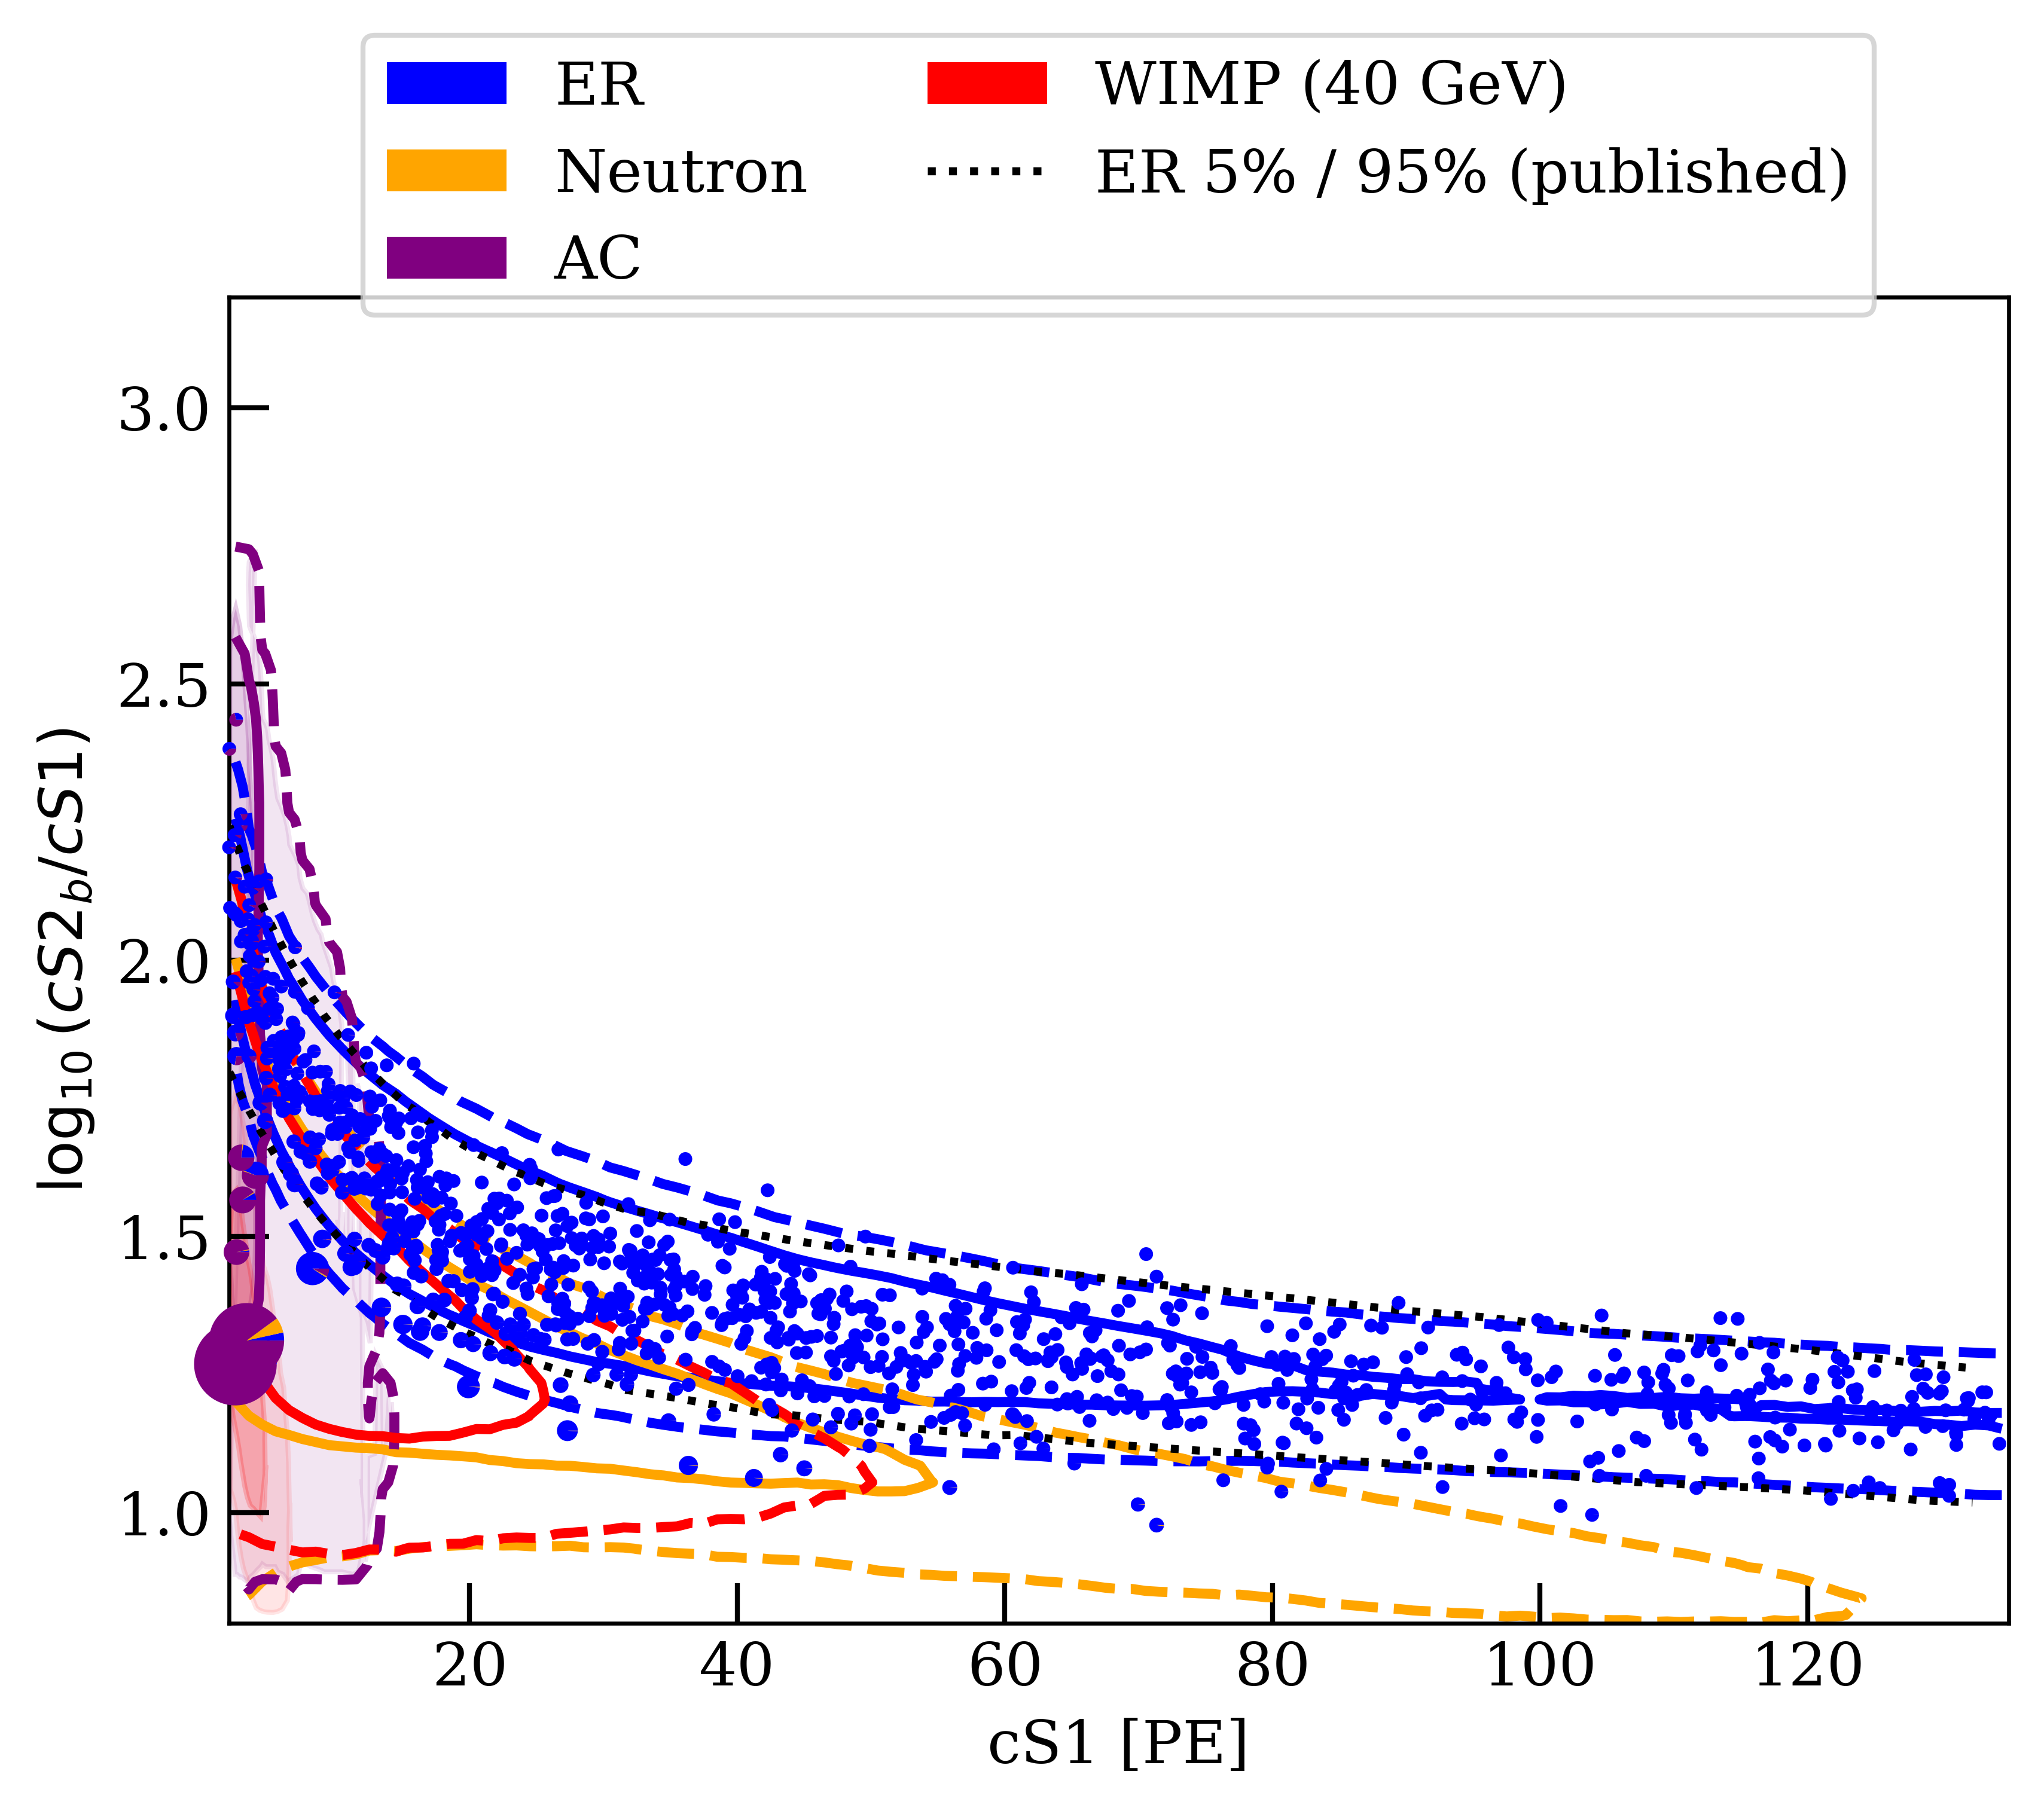

PandaX-4T Run1 analysis space (cS1, log10(cS2_b/cS1))
True
True


True
True


True
True


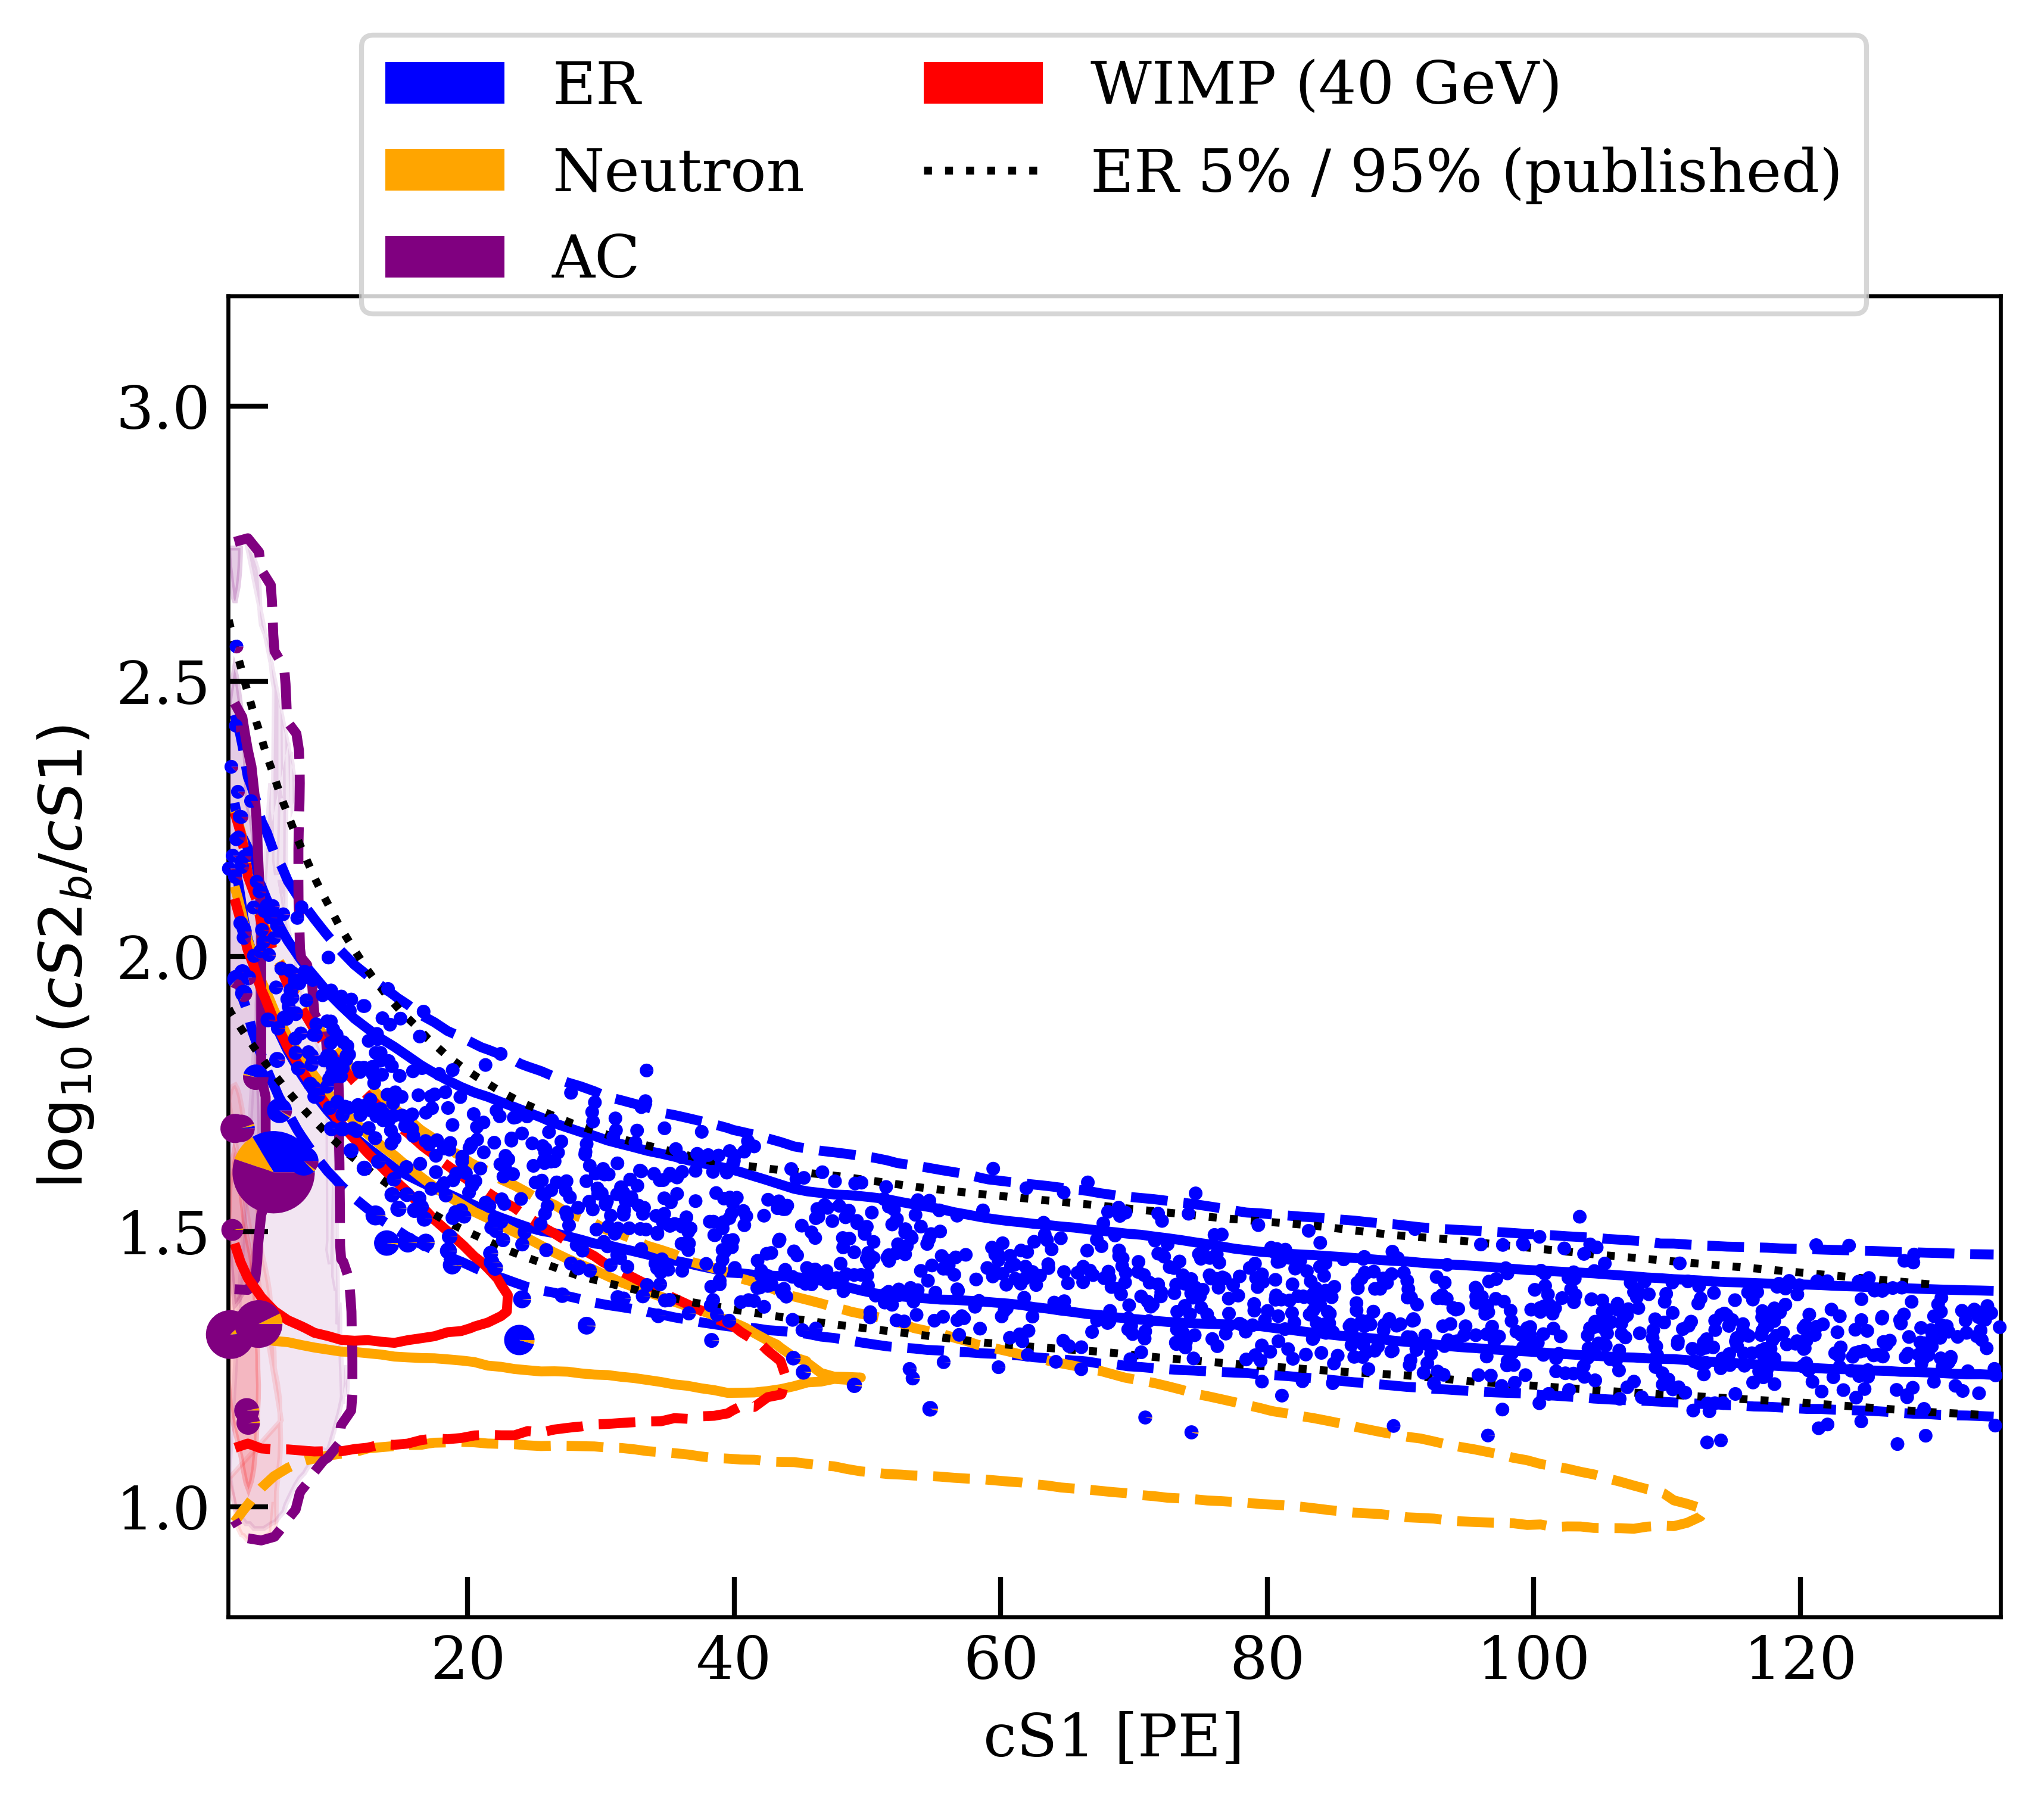

In [5]:
# Background + signal contours with per-event composition pie charts, per run.
# ER = other_er + tritium + xe124 (+ xe127 for Run0); NR bkg = neutron;
# AC and WIMP overlaid with the digitized published 1/2 sigma contours; WIMP = 40 GeV.
# The published 5% / 95% ER band edges are overlaid on the ER contour.
from matplotlib.lines import Line2D

pandax4t_signal_mass = 40

pandax4t_er_bkgs = {
    "pandax4t_run0": ["other_er", "tritium", "xe124", "xe127"],
    "pandax4t_run1": ["other_er", "tritium", "xe124"],
}
pandax4t_ac_contours = {
    "pandax4t_run0": {
        "one_sigma_contour_fname": "pandax4t_run0_ac_1sigma.csv",
        "two_sigma_contour_fname": "pandax4t_run0_ac_2sigma.csv",
    },
    "pandax4t_run1": {
        "one_sigma_contour_fname": [
            "pandax4t_run1_ac_1sigma_0.csv",
            "pandax4t_run1_ac_1sigma_1.csv",
        ],
        "two_sigma_contour_fname": "pandax4t_run1_ac_2sigma.csv",
    },
}
pandax4t_wimp_contours = {
    "pandax4t_run0": {
        "one_sigma_contour_fname": "pandax4t_run0_wimp_1sigma.csv",
        "two_sigma_contour_fname": "pandax4t_run0_wimp_2sigma.csv",
    },
    "pandax4t_run1": {
        "one_sigma_contour_fname": "pandax4t_run1_wimp_1sigma.csv",
        "two_sigma_contour_fname": "pandax4t_run1_wimp_2sigma.csv",
    },
}
# Published 5% / 95% ER band edges in (cS1, log10(cS2_b/cS1)).
pandax4t_er_band = {
    "pandax4t_run0": ["pandax4t_run0_er_lower_5p.csv", "pandax4t_run0_er_upper_5p.csv"],
    "pandax4t_run1": ["pandax4t_run1_er_lower_5p.csv", "pandax4t_run1_er_upper_5p.csv"],
}
pandax4t_legend_kwargs = {"loc": "upper center", "bbox_to_anchor": (0.5, 1.22), "ncol": 2}

for experiment_name in ("pandax4t_run0", "pandax4t_run1"):
    run_label = "Run0" if experiment_name.endswith("run0") else "Run1"
    print(f"PandaX-4T {run_label} analysis space (cS1, log10(cS2_b/cS1))")
    content_specs = [
        {
            "type": "best_fit_bkg",
            "plot_contour_diamx": "contour",
            "plot_contour_literature": False,
            "component_name": "ER",
            "bkg_to_include": pandax4t_er_bkgs[experiment_name],
            "color": "blue",
            "label": "ER",
        },
        {
            "type": "best_fit_bkg",
            "plot_contour_diamx": "contour",
            "plot_contour_literature": False,
            "component_name": "NR bkg",
            "bkg_to_include": ["neutron"],
            "color": "orange",
            "label": "Neutron",
        },
        {
            "type": "bkg",
            "plot_contour_diamx": "contour",
            "plot_contour_literature": True,
            "component_name": "ac",
            "color": "purple",
            "log10_contour": False,
            "label": "AC",
            **pandax4t_ac_contours[experiment_name],
        },
        {
            "type": "signal",
            "plot_contour_diamx": "contour",
            "plot_contour_literature": True,
            "component_name": "wimp",
            "color": "red",
            "log10_contour": False,
            "label": f"WIMP ({pandax4t_signal_mass} GeV)",
            **pandax4t_wimp_contours[experiment_name],
        },
    ]
    fig, ax = plot_contours_and_pies(
        pandax4t_st,
        {
            "experiment_name": experiment_name,
            "signal_parameter_value": pandax4t_signal_mass,
            "content_specs": content_specs,
            "fig_specs": {
                "figure_size": [6.4, 4.8],
                "axis_names": ["cs1", "logcs2_s1"],
                "axis_labels": ["cS1 [PE]", r"$\log_{10}(cS2_b/cS1)$"],
                "axis_limits": [[2, 135], [0.8, 3.2]],
                "axis_scales": ["linear", "linear"],
                "contour_linestyles": ["--", "-"],
                "plot_pie_charts": True,
                "pie_size_min": 1,
                "pie_size_max": 6,
                "pie_axis_width": 0.01,
                "pie_axis_height": 0.01,
                "legend_kwargs": pandax4t_legend_kwargs,
            },
        },
    )
    # Overlay the published 5% / 95% ER band edges, and add a legend entry.
    legend_handles = [Patch(facecolor=cs["color"], label=cs["label"]) for cs in content_specs]
    er_band = pandax4t_er_band[experiment_name]
    if er_band is not None:
        for fname in er_band:
            band = np.loadtxt(f"../diamx/data/{fname}", delimiter=",")
            ax.plot(band[:, 0], band[:, 1], color="black", ls=":", lw=1.6)
        legend_handles.append(
            Line2D([0], [0], color="black", ls=":", lw=1.6, label="ER 5% / 95% (published)")
        )
    ax.legend(handles=legend_handles, **pandax4t_legend_kwargs)
    plt.savefig(
        f"../plots/{experiment_name}_cs1_logcs2s1_contours.png",
        dpi=600,
        bbox_inches="tight",
    )
    plt.show()


### Best-fit background rates
Best-fit background rates (events, = rate multiplier $\times$ nominal $\times$ livetime)
with their uncertainties, plus the best-fit signal expectation, from the combined
Run0+Run1 fit at $m_\chi = 40$ GeV/$c^2$.

In [7]:
pandax4t_st.print_best_fit(pandax4t_signal_mass)


True
True


pandax4t_run0
              Nominal     Best fit
other_er     504 ± 16     510 ± 14
tritium           556     570 ± 30
xe124       2.3 ± 0.6    2.3 ± 0.6
xe127       7.7 ± 0.4    7.7 ± 0.4
neutron     0.6 ± 0.3    0.6 ± 0.3
b8        0.30 ± 0.10  0.31 ± 0.10
ac             11 ± 3       11 ± 3
Signal best fit: 3.777377035764935e-07

pandax4t_run1
              Nominal     Best fit
other_er    1230 ± 30    1240 ± 20
tritium           114     100 ± 30
xe124       4.1 ± 1.1    4.1 ± 1.1
neutron     1.1 ± 0.6    1.1 ± 0.6
b8        0.70 ± 0.20  0.74 ± 0.19
ac             13 ± 4       12 ± 3
Signal best fit: 6.995142659741094e-07



Running inference (Pool):   0%|          | 0/25 [00:00<?, ?it/s]

/home/mhliu/Documents/private_nt_aux_files/ntauxfiles/interface.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/mhliu/Documents/private_nt_aux_files/ntauxfiles/interface.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/mhliu/Documents/private_nt_aux_files/ntauxfiles/interface.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resou

XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform
Using aptext package from https://github.com/XENONnT/applefiles
True
True
XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform
Using aptext package from https://github.com/XENONnT/applefiles
True
True
XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform
Using aptext package from https://github.com/XENONnT/applefiles
True
True
XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform
Using aptext package from https://github.com/XENONnT/applefiles
True
True
XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform
Using aptext package from https://github.com/XENONnT/applefiles
True
True
XLA_PYTHON_CLIENT_PREALLOCATE is set to false
XLA_PYTHON_CLIENT_ALLOCATOR is set to platform
Using aptext package from https://github.com/XENONnT/applefiles
True
Tru

Running inference (Pool):   4%|▍         | 1/25 [00:32<12:55, 32.31s/it]

True
True


...

Running inference (Pool):  88%|████████▊ | 22/25 [02:08<00:14,  4.99s/it]

Running inference (Pool):  92%|█████████▏| 23/25 [02:13<00:09,  4.92s/it]

Running inference (Pool):  96%|█████████▌| 24/25 [02:22<00:06,  6.23s/it]

Running inference (Pool): 100%|██████████| 25/25 [02:23<00:00,  4.53s/it]

Running inference (Pool): 100%|██████████| 25/25 [02:23<00:00,  5.75s/it]

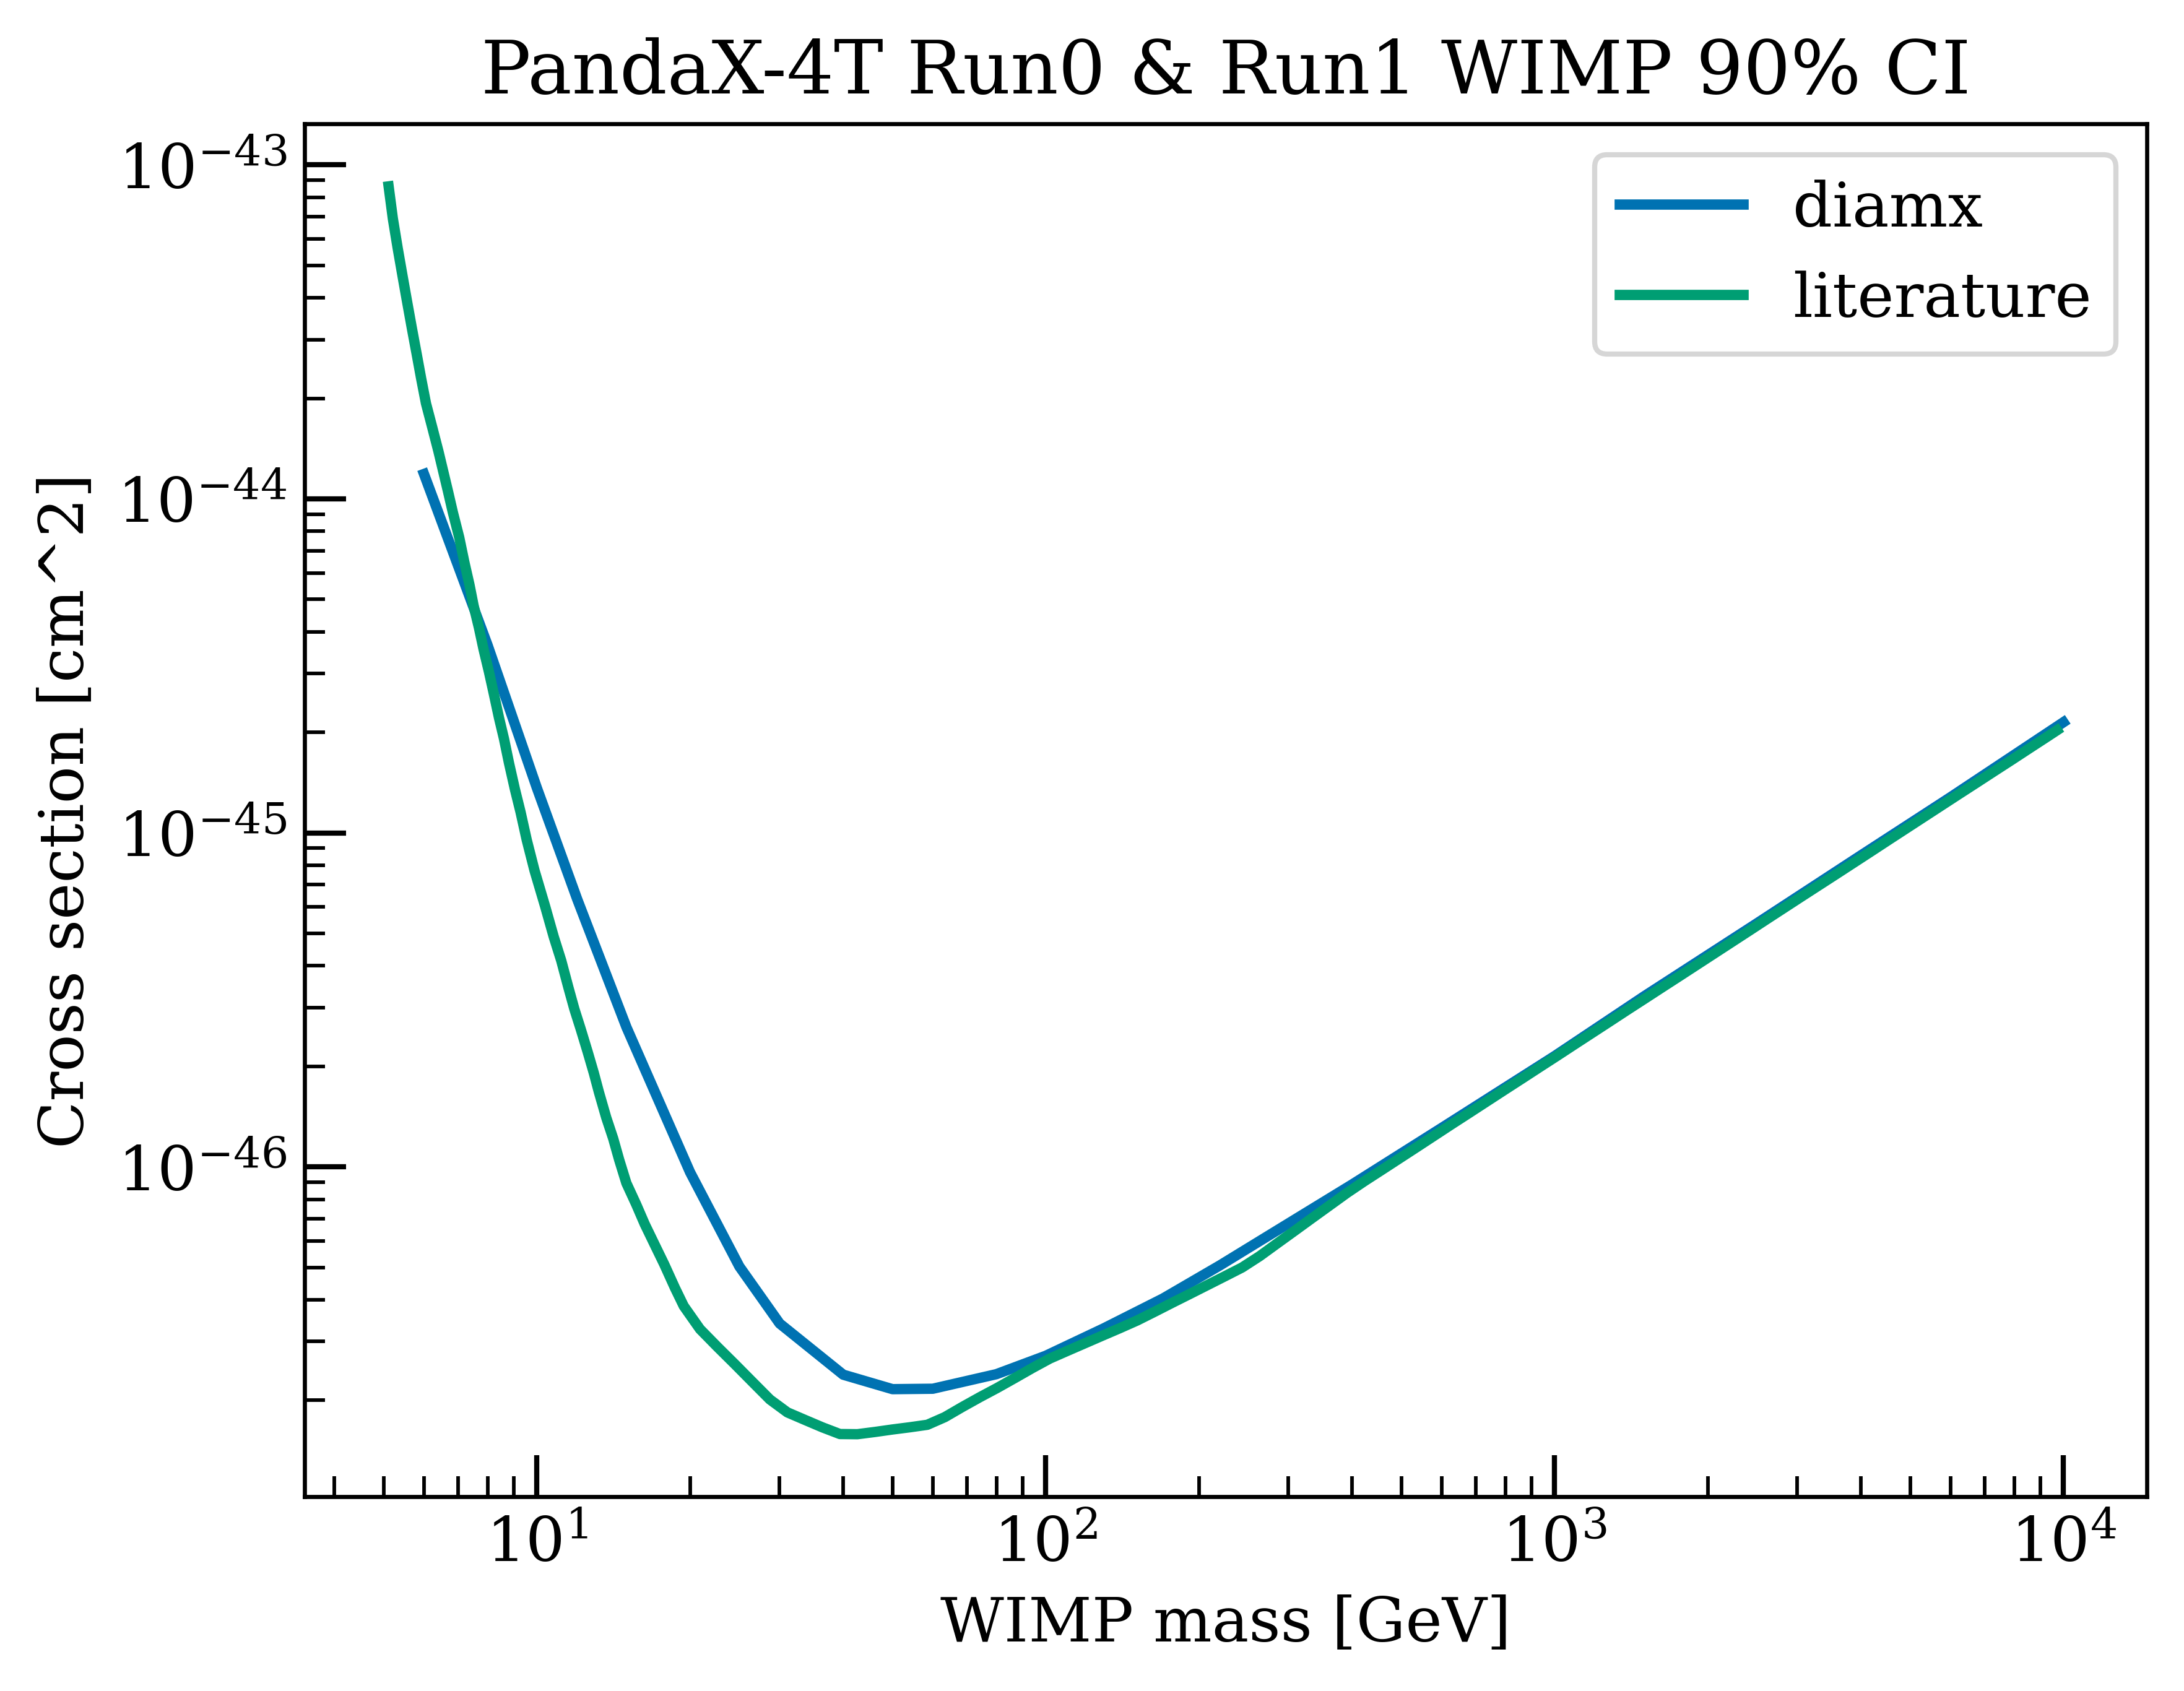

In [8]:
# Reproducing Fig. 3 (upper limit)
# pandax4t_st.run_inference(output_file_name="pandax4t_run01_wimp_ci.csv")
diamx.run_inference_pool(
    pandax4t_st,
    output_file_name="pandax4t_run01_wimp_ci.csv",
    processes=8,
)
ci = np.loadtxt("./diamx_output/pandax4t_run01_wimp_ci.csv", delimiter=",")
plt.plot(ci[:, 0], ci[:, 2] * 1e-44, label="diamx")
ci_literature = np.loadtxt("../diamx/data/pandax4t_run01_wimp_ci.csv", delimiter=",")
plt.plot(ci_literature[:, 0], ci_literature[:, 1], label="literature")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("WIMP mass [GeV]")
plt.ylabel("Cross section [cm^2]")
plt.title("PandaX-4T Run0 & Run1 WIMP 90% CI")
plt.savefig("../plots/pandax4t_run01_wimp_ci.png", dpi=600, bbox_inches="tight")

### Analysis space (Fig. 1 style): data with NR/ER bands

The Run0+Run1 candidate events in $(cS1, \log_{10}(cS2_b/cS1))$, with the NR and ER median $\pm 2\sigma$ bands simulated over a uniform recoil-energy range. Events below the NR median (the WIMP search region) are highlighted; PandaX reports 24 such events (12 Run0 + 12 Run1).

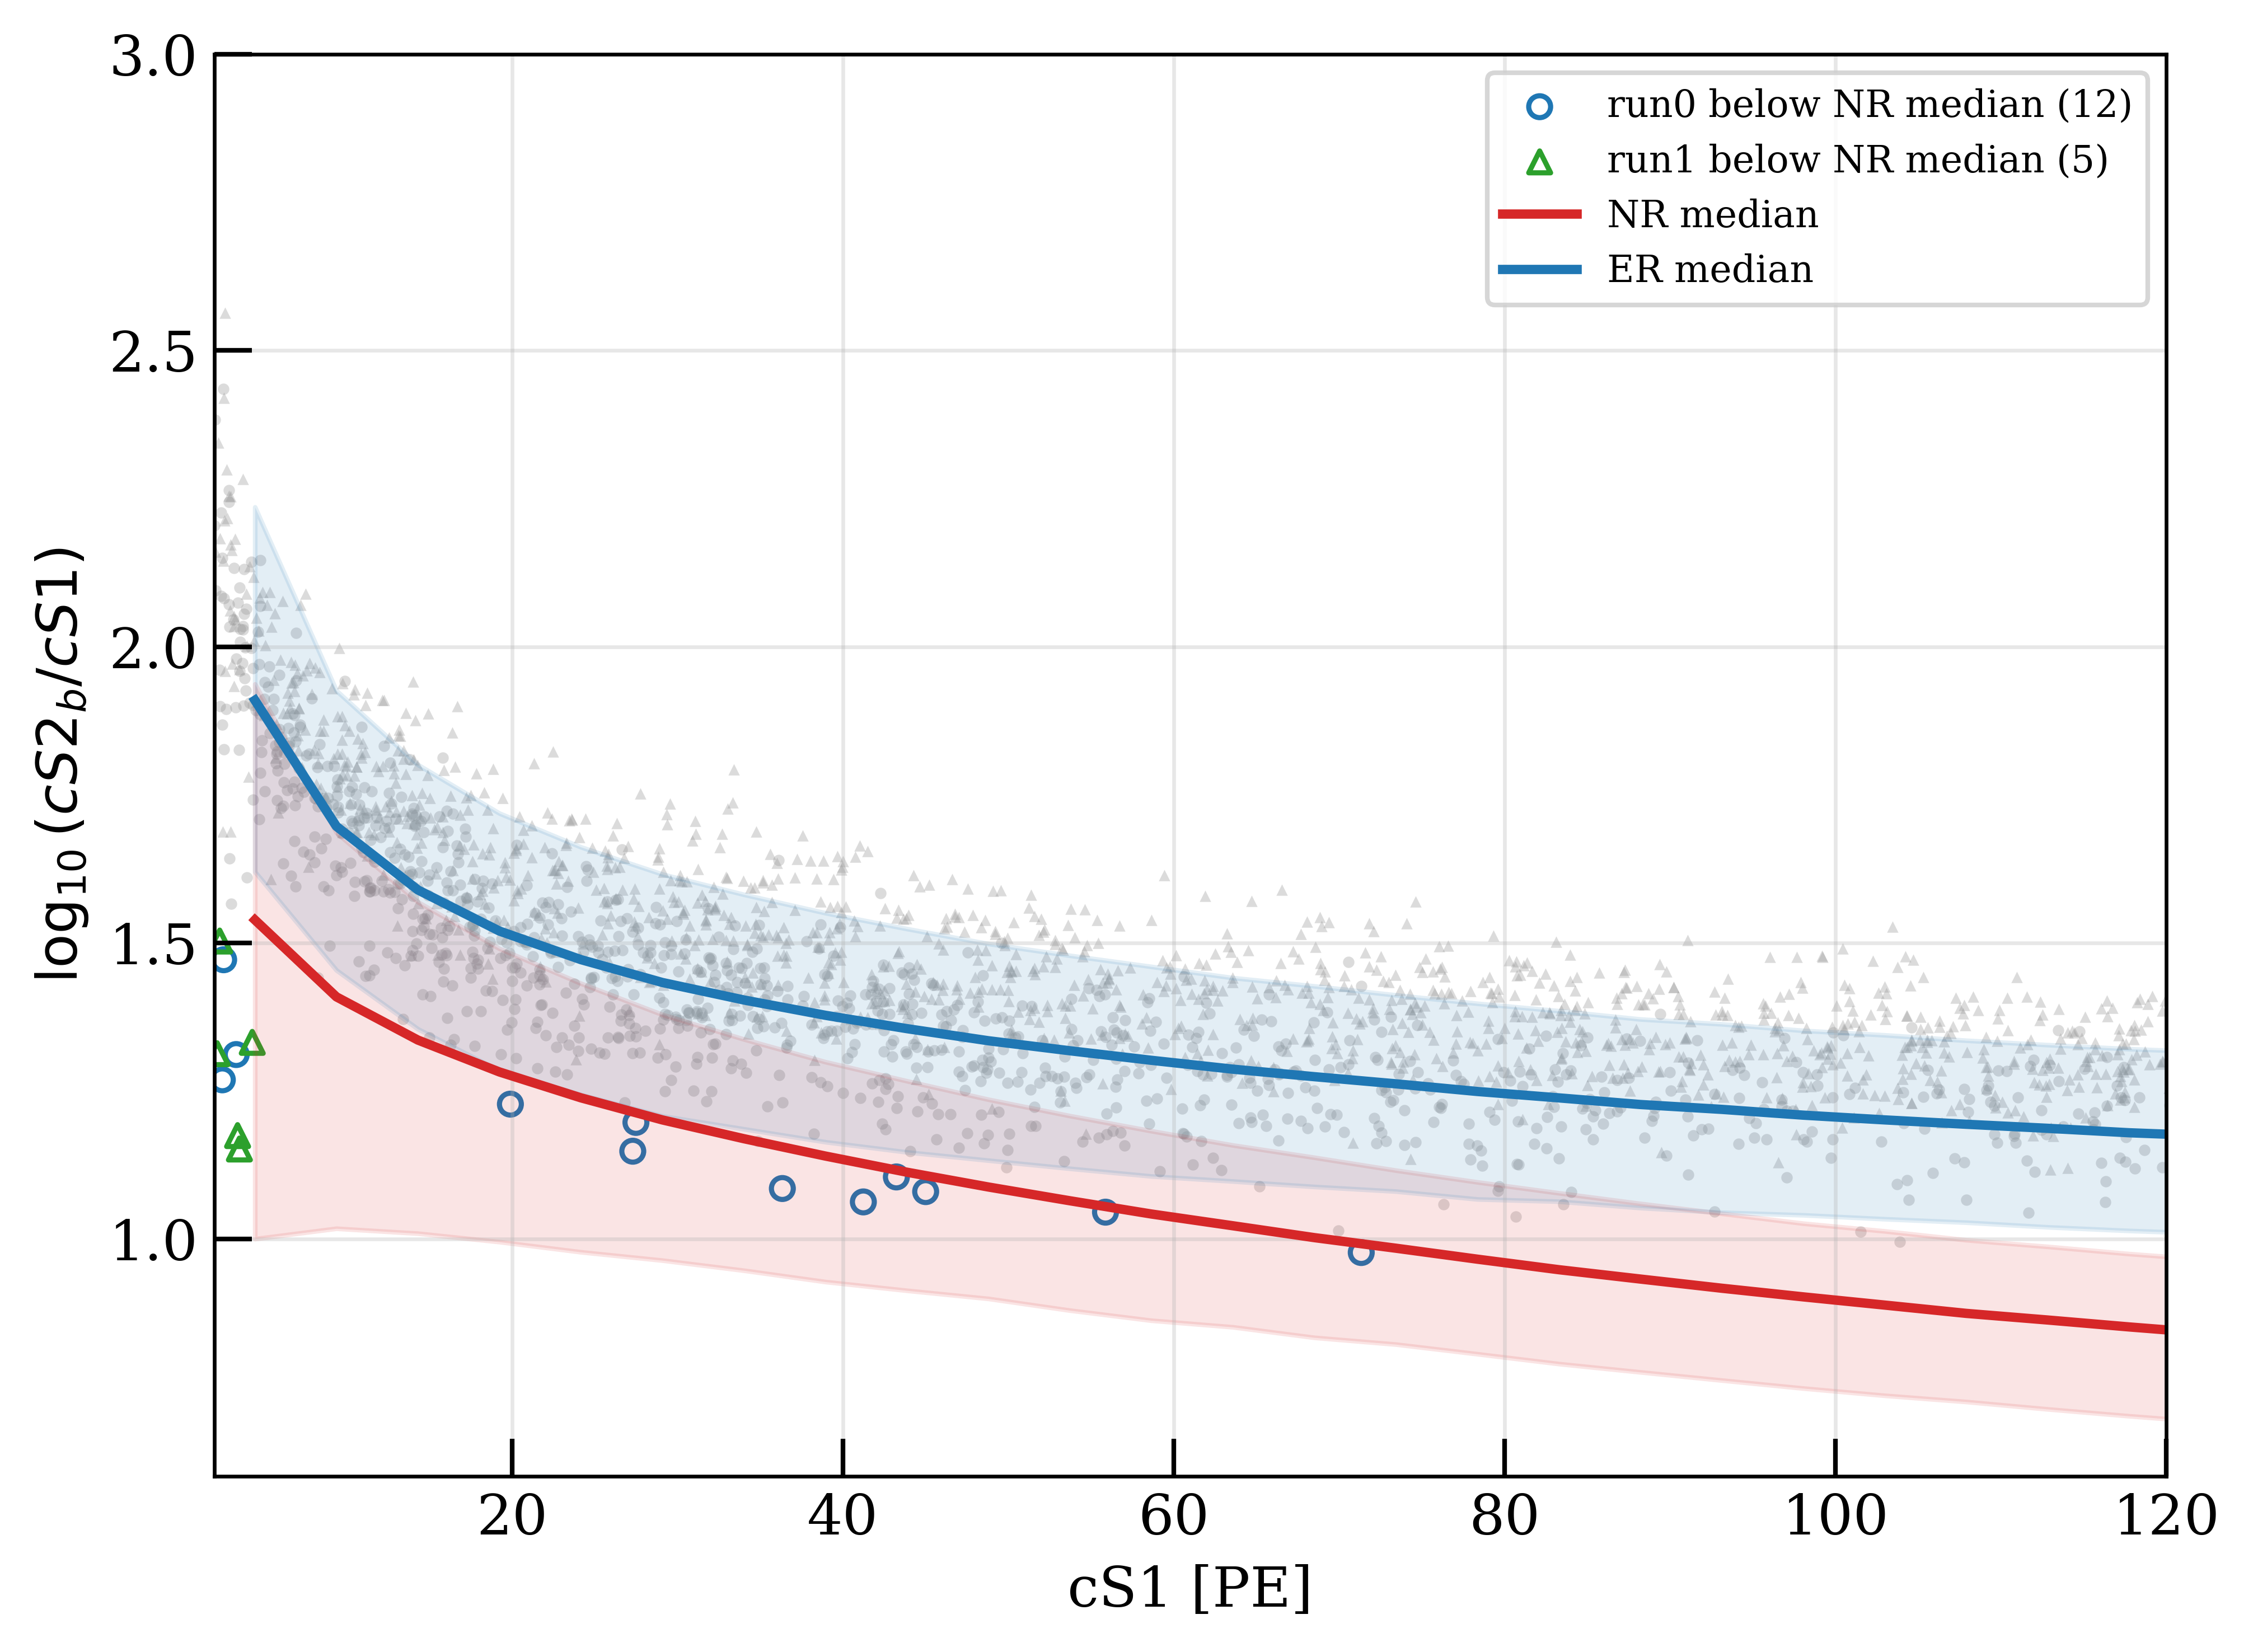

In [6]:
# Fig. 1 style: data + NR/ER bands in the (cS1, log10(cS2_b/cS1)) analysis space.
import json
import appletree as apt
from diamx.appletree import get_file_path_diamx
from diamx.appletree.components.nr_pandax4t import NRPandaX4T
from diamx.appletree.components.er_pandax4t import ERFlatPandaX4T

def simulate_band(comp_cls, stem, e_lo, e_hi, n=2_000_000):
    """Simulate a recoil band -> (cS1, log10(cS2_b/cS1)) over a uniform energy range."""
    instruct = json.load(open(get_file_path_diamx(f"{stem}.json")))
    instruct.update({"lower_energy": e_lo, "upper_energy": e_hi})
    pm = apt.Parameter(get_file_path_diamx(f"{stem}_par.json")); pm.sample_prior()
    params = dict(pm.get_all_parameter())
    params.update(json.load(open(get_file_path_diamx(f"{stem}_model.json"))))
    for s in ("elife_sigma", "s1_cut_acc_sigma", "s2_cut_acc_sigma"):
        params[s] = 0.0
    comp = comp_cls(stem, llh_name=stem)
    comp.deduce(data_names=["cs1", "cs2"], force_no_eff=True)
    defaults = {}
    for plugin_name, _, _ in comp.worksheet:
        for cname, cfg in eval(f"apt.plugins.{plugin_name}").takes_config.items():
            try:
                defaults[cname] = cfg.get_default()
            except ValueError:
                pass
    defaults.update(instruct)
    apt.share.clear_cache()
    comp.set_config(pandax4t_st.experiment_instances[0].file_path_substitution(defaults))
    comp.deduce(data_names=["cs1", "cs2"], force_no_eff=True); comp.compile()
    _, out = comp.simulate(apt.get_key(), n, params)
    cs1, cs2 = np.asarray(out[0]), np.asarray(out[1])
    keep = (cs1 > 1) & (cs2 > 0)
    return cs1[keep], np.log10(cs2[keep] / cs1[keep])

edges = np.linspace(2, 135, 28); centers = 0.5 * (edges[:-1] + edges[1:])
bands = {}
for label, (comp_cls, stem, e_lo, e_hi) in {
    "NR": (NRPandaX4T, "pandax4t_run0_nr", 1.0, 120.0),
    "ER": (ERFlatPandaX4T, "pandax4t_run0_er", 0.5, 35.0),
}.items():
    c1, y = simulate_band(comp_cls, stem, e_lo, e_hi)
    idx = np.digitize(c1, edges) - 1
    pcts = np.array([np.percentile(y[idx == k], [2.5, 50, 97.5]) if (idx == k).sum() > 200
                     else [np.nan] * 3 for k in range(len(centers))])
    bands[label] = pcts[:, 1], pcts[:, 0], pcts[:, 2]

fig, ax = plt.subplots(figsize=(7.5, 5.5))
nr_med = bands['NR'][0]; g_nr = np.isfinite(nr_med)
nr_median_at = lambda x: np.interp(x, centers[g_nr], nr_med[g_nr])
for exp_inst, marker, color in zip(pandax4t_st.experiment_instances, ("o", "^"), ("tab:blue", "tab:green")):
    d = exp_inst.get_data()
    below = d["logcs2_s1"] < nr_median_at(d["cs1"])
    ax.scatter(d["cs1"][~below], d["logcs2_s1"][~below], s=6, marker=marker, c="0.6", alpha=0.35, lw=0)
    ax.scatter(d["cs1"][below], d["logcs2_s1"][below], s=22, marker=marker, facecolor="none",
               edgecolor=color, lw=1.1,
               label=f"{exp_inst.experiment_name.split(chr(95))[1]} below NR median ({int(below.sum())})")
for label, color in (("NR", "tab:red"), ("ER", "tab:blue")):
    med, lo2, hi2 = bands[label]; g = np.isfinite(med)
    ax.plot(centers[g], med[g], "-", color=color, lw=2, label=f"{label} median")
    ax.fill_between(centers[g], lo2[g], hi2[g], color=color, alpha=0.12)
ax.set_xlim(2, 120); ax.set_ylim(0.6, 3.0)
ax.set_xlabel("cS1 [PE]"); ax.set_ylabel(r"$\log_{10}(cS2_b/cS1)$")
ax.legend(fontsize=8, loc="upper right"); ax.grid(alpha=0.3)
plt.savefig("../plots/pandax4t_run01_analysis_space.png", dpi=600, bbox_inches="tight")

### NR median & ER 5% / 95% band: diamx vs published, in $(cS1, \log_{10} cS2_b)$ space
Same per-run validation as above but with the y-axis as $\log_{10}(cS2_b)$ instead of the ratio $\log_{10}(cS2_b/cS1)$ (converted via $\log_{10}cS2_b = \log_{10}(cS2_b/cS1) + \log_{10}cS1$). In this space g2 is a pure vertical shift and g1 a pure horizontal one.

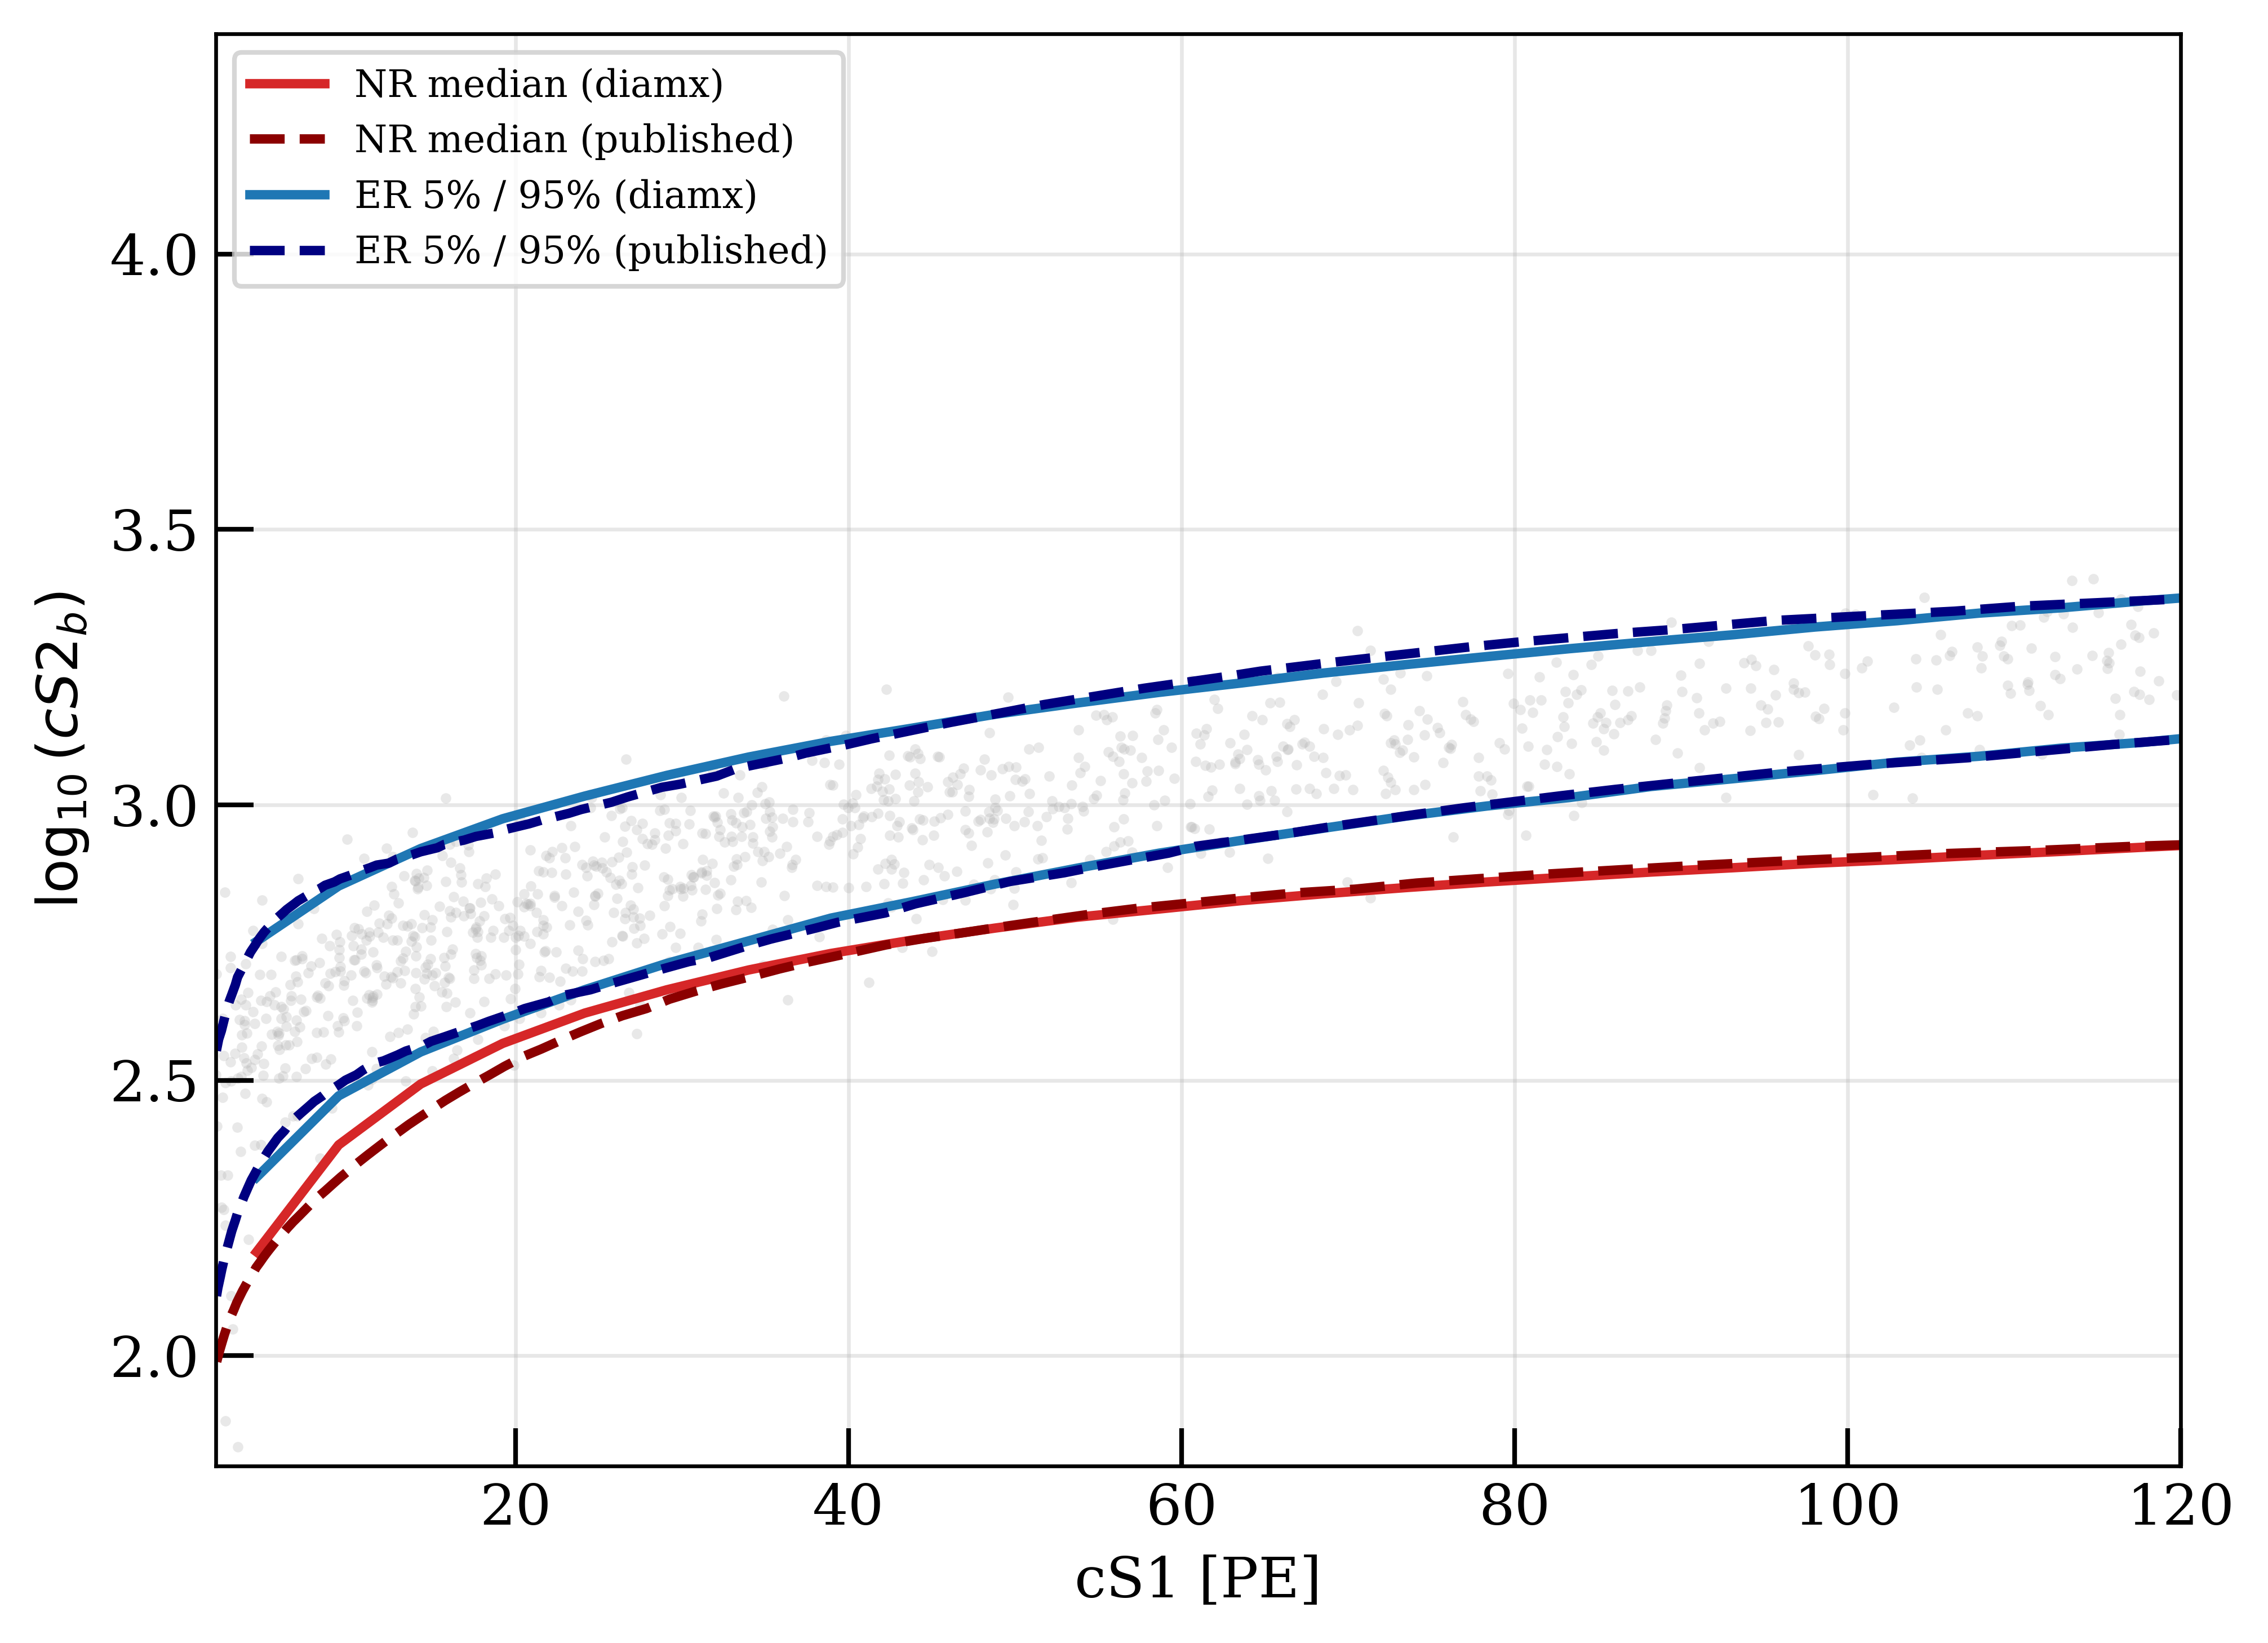

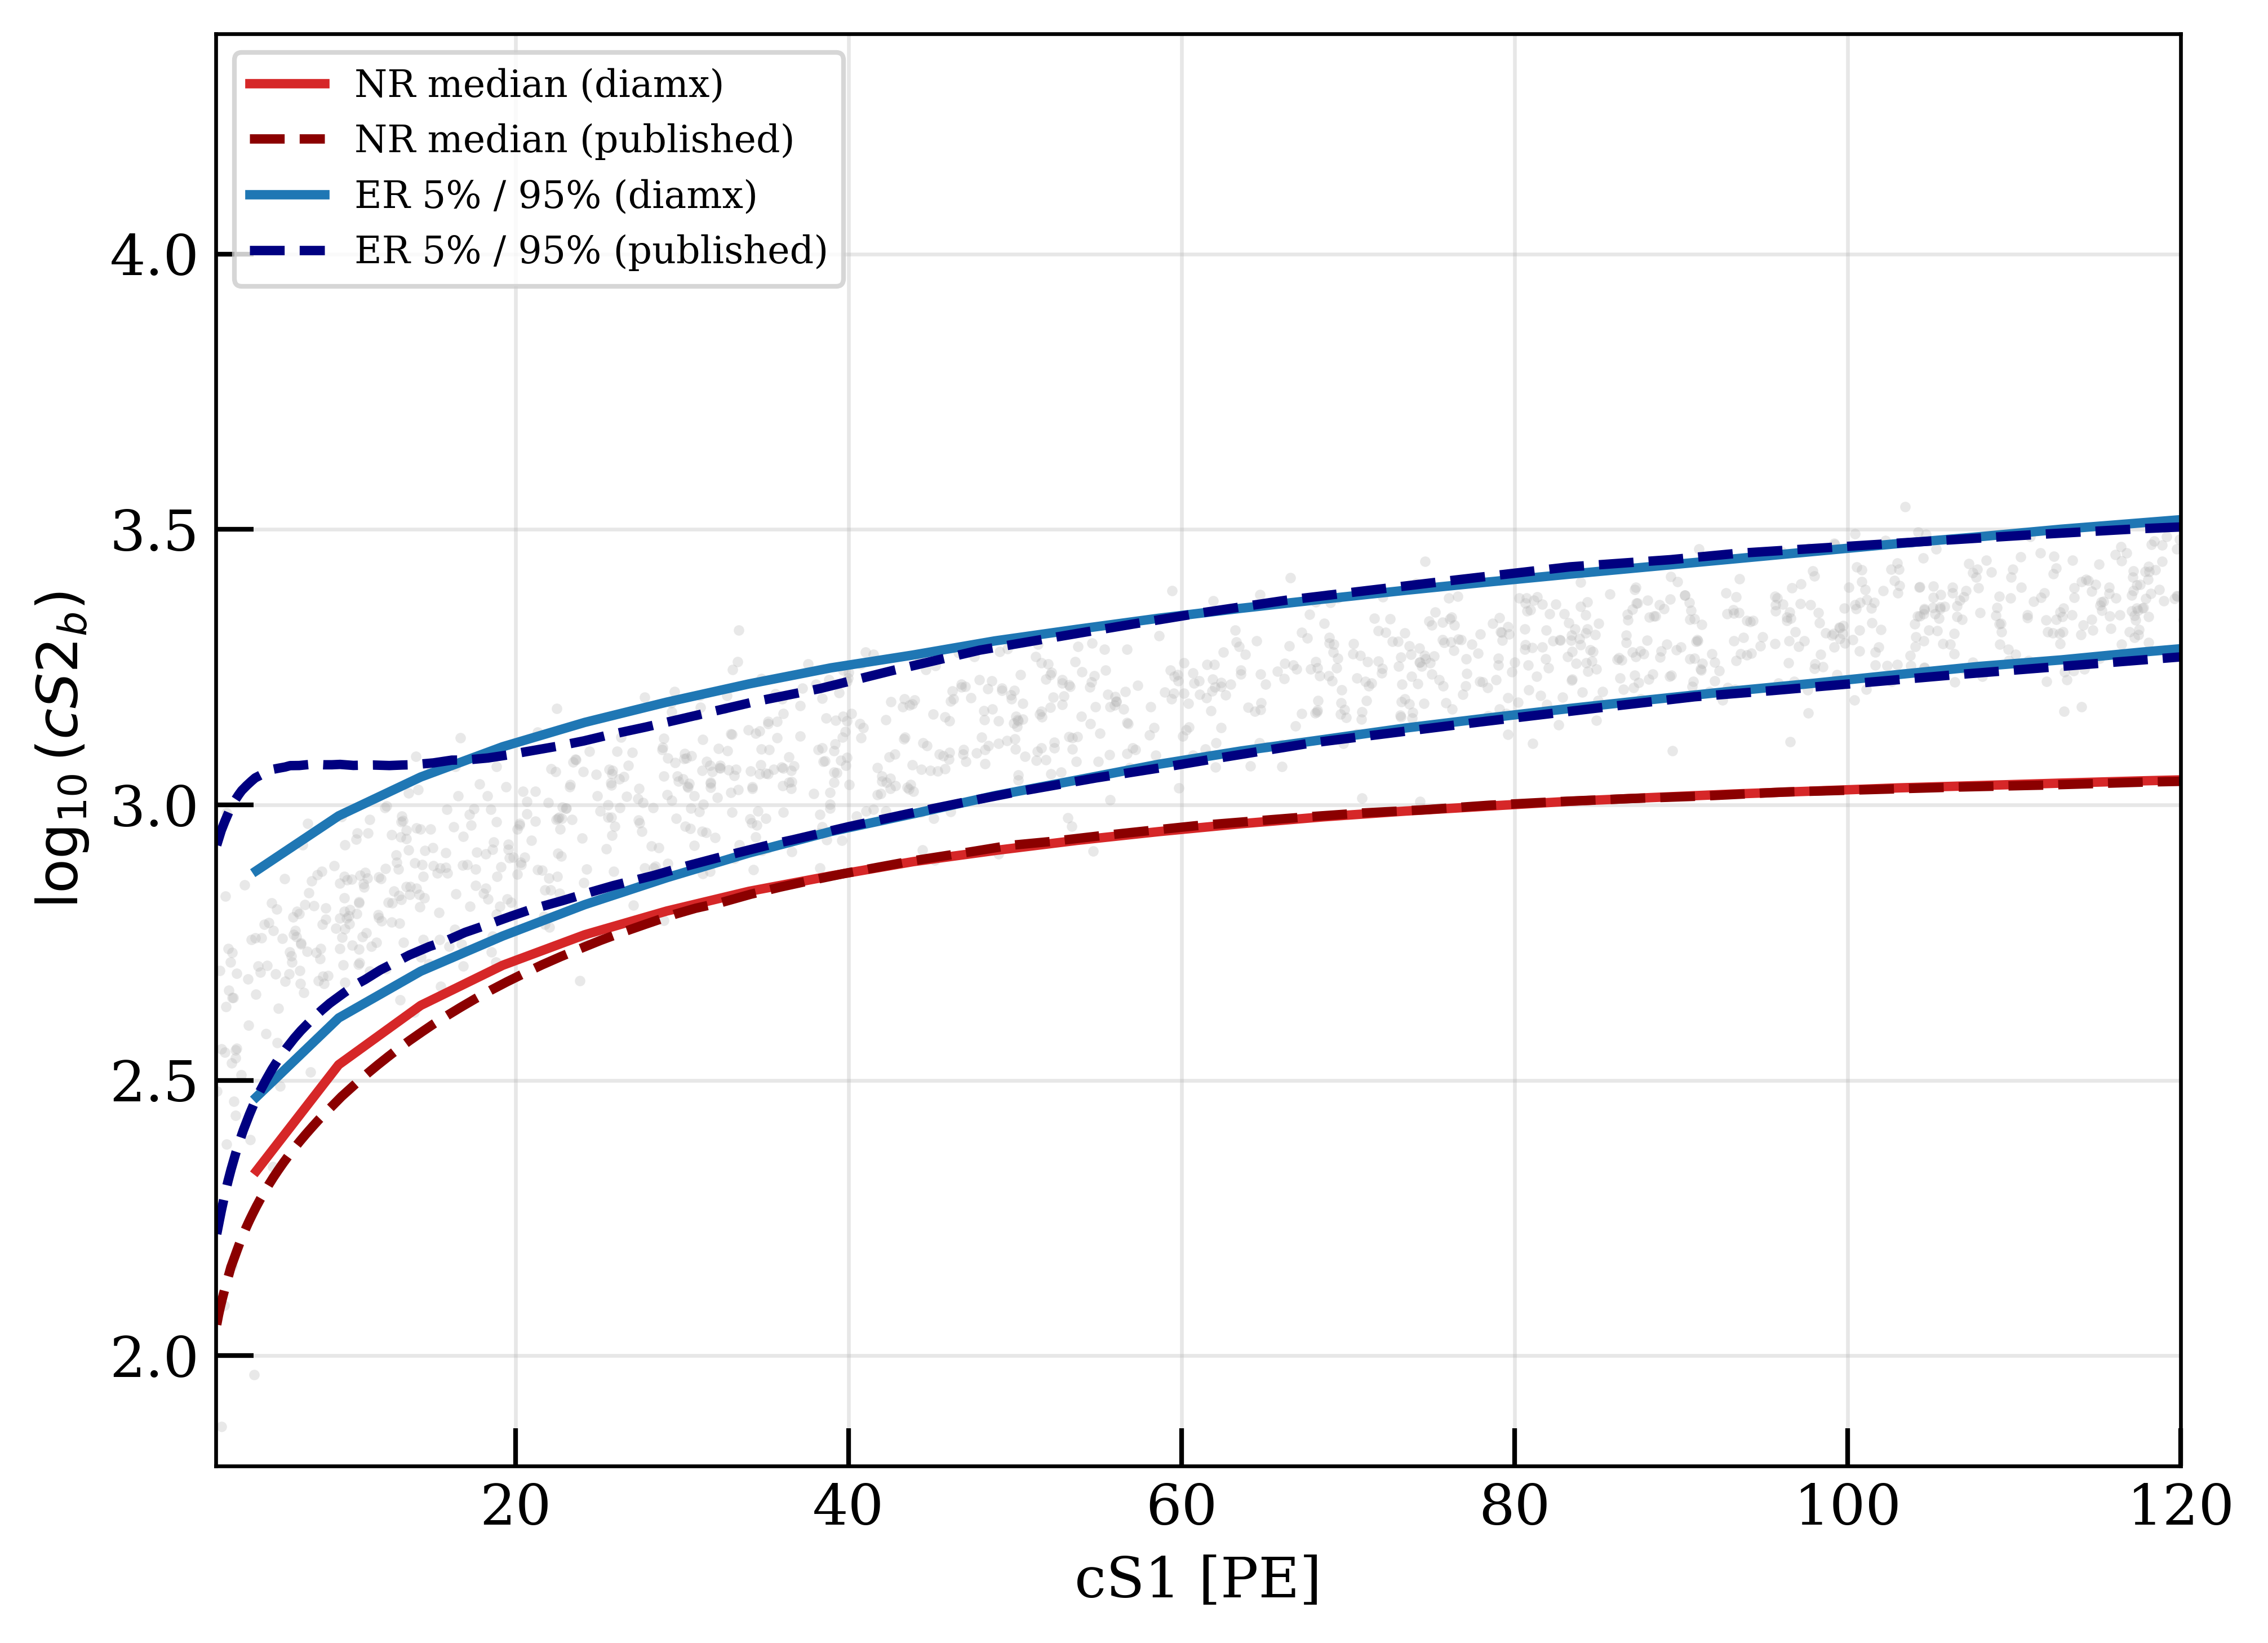

In [7]:
# Per-run validation: diamx-computed vs published NR median and ER 5% / 95% band edges,
# in (cS1, log10(cS2_b)) space. simulate_band (from the previous cell) returns
# log10(cS2_b/cS1); convert per event: log10(cS2_b) = log10(cS2_b/cS1) + log10(cS1).
from diamx.appletree.components.nr_pandax4t import NRPandaX4T
from diamx.appletree.components.er_pandax4t import ERFlatPandaX4T

val_edges = np.linspace(2, 135, 28)
val_centers = 0.5 * (val_edges[:-1] + val_edges[1:])


def _band_percentiles(c1, y, qs, min_count=200):
    idx = np.digitize(c1, val_edges) - 1
    return np.array([
        np.percentile(y[idx == k], qs) if (idx == k).sum() > min_count else [np.nan] * len(qs)
        for k in range(len(val_centers))
    ])


for experiment_name, exp_inst in zip(
    ("pandax4t_run0", "pandax4t_run1"), pandax4t_st.experiment_instances
):
    run_label = "Run0" if experiment_name.endswith("run0") else "Run1"
    # diamx-simulated bands for this run; convert log10(cS2_b/cS1) -> log10(cS2_b)
    nr_c1, nr_yr = simulate_band(NRPandaX4T, f"{experiment_name}_nr", 1.0, 120.0)
    er_c1, er_yr = simulate_band(ERFlatPandaX4T, f"{experiment_name}_er", 0.5, 35.0)
    nr_logcs2 = nr_yr + np.log10(nr_c1)
    er_logcs2 = er_yr + np.log10(er_c1)
    nr_med = _band_percentiles(nr_c1, nr_logcs2, [50])[:, 0]
    er_lohi = _band_percentiles(er_c1, er_logcs2, [5, 95])

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    d = exp_inst.get_data()
    d_logcs2 = d["logcs2_s1"] + np.log10(d["cs1"])  # published data in log10(cS2_b)
    ax.scatter(d["cs1"], d_logcs2, s=5, c="0.7", alpha=0.3, lw=0, zorder=1)

    # NR median: diamx (solid red) vs published (dashed dark red)
    g = np.isfinite(nr_med)
    ax.plot(val_centers[g], nr_med[g], "-", color="tab:red", lw=2, label="NR median (diamx)")
    pub_nr = np.loadtxt(f"../diamx/data/{experiment_name}_nr_median.csv", delimiter=",")
    ax.plot(pub_nr[:, 0], pub_nr[:, 1] + np.log10(pub_nr[:, 0]), "--", color="darkred", lw=2,
            label="NR median (published)")

    # ER 5% / 95%: diamx (solid blue) vs published (dashed navy)
    ge = np.isfinite(er_lohi[:, 0])
    ax.plot(val_centers[ge], er_lohi[ge, 0], "-", color="tab:blue", lw=2, label="ER 5% / 95% (diamx)")
    ax.plot(val_centers[ge], er_lohi[ge, 1], "-", color="tab:blue", lw=2)
    for j, fname in enumerate(
        (f"{experiment_name}_er_lower_5p.csv", f"{experiment_name}_er_upper_5p.csv")
    ):
        pub = np.loadtxt(f"../diamx/data/{fname}", delimiter=",")
        ax.plot(pub[:, 0], pub[:, 1] + np.log10(pub[:, 0]), "--", color="navy", lw=2,
                label="ER 5% / 95% (published)" if j == 0 else None)

    ax.set_xlim(2, 120); ax.set_ylim(1.8, 4.4)
    ax.set_xlabel("cS1 [PE]"); ax.set_ylabel(r"$\log_{10}(cS2_b)$")
    ax.legend(fontsize=8, loc="upper left"); ax.grid(alpha=0.3)
    plt.savefig(f"../plots/{experiment_name}_nr_median_er_band_validation_logcs2.png", dpi=600, bbox_inches="tight")
    plt.show()


### Xe124 double-electron-capture model with a reduced charge yield

The PandaX-4T analysis treats the $^{124}\text{Xe}$ double electron capture (DEC) and the
$^{127}\text{Xe}$ L-shell electron capture with the ordinary $\beta$-decay charge yield.
Following the XENONnT and LZ analyses, we instead model their **reduced charge yield**:
the $^{127}\text{Xe}$ L-shell and the $^{124}\text{Xe}$ LM shell (5.98 keV) share
$Q_L/Q_\beta = Q_{LM}/Q_\beta = 0.88$ (the LZ WS2024 value, at a similar drift field),
while the $^{124}\text{Xe}$ LL shell (10.0 keV) has a lower, **free** $Q_{LL}/Q_\beta$ that is
shared between Run0 and Run1. This uses `config/pandax4t_run01_wimp_config_dec.json`,
where $^{124}\text{Xe}$ is a shaped background. Below we draw the $^{127}\text{Xe}$ and $^{124}\text{Xe}$
contours separately (so the quenched DEC peaks are visible, sitting below the ER band)
and report the best-fit $Q_{LL}/Q_\beta$.

In [8]:
pandax4t_dec_st = diamx.Context(
    os.path.join(diamx_dir, "..", "config", "pandax4t_run01_wimp_config_dec.json"),
)
pandax4t_dec_st.register_experiment(diamx.experiments.PandaX4TRun0)
pandax4t_dec_st.register_experiment(diamx.experiments.PandaX4TRun1)
pandax4t_dec_st.generate_templates()

Generating background templates for pandax4t_run0:   0%|          | 0/6 [00:00<?, ?it/s]

Generating background templates for pandax4t_run0: 100%|██████████| 6/6 [00:00<00:00, 1344.04it/s]

Generating shaped background templates for pandax4t_run0:   0%|          | 0/12 [00:00<?, ?it/s]

Generating shaped background templates for pandax4t_run0: 100%|██████████| 12/12 [00:00<00:00, 1514.74it/s]

Generating signal templates for pandax4t_run0:   0%|          | 0/25 [00:00<?, ?it/s]

...

Generating background templates for pandax4t_run1: 100%|██████████| 5/5 [00:00<00:00, 1520.45it/s]

Generating shaped background templates for pandax4t_run1:   0%|          | 0/12 [00:00<?, ?it/s]

Generating shaped background templates for pandax4t_run1: 100%|██████████| 12/12 [00:00<00:00, 1544.77it/s]

Generating signal templates for pandax4t_run1:   0%|          | 0/25 [00:00<?, ?it/s]

Generating signal templates for pandax4t_run1: 100%|██████████| 25/25 [00:00<00:00, 1610.12it/s]

True


True


True


True


True


True


True


True


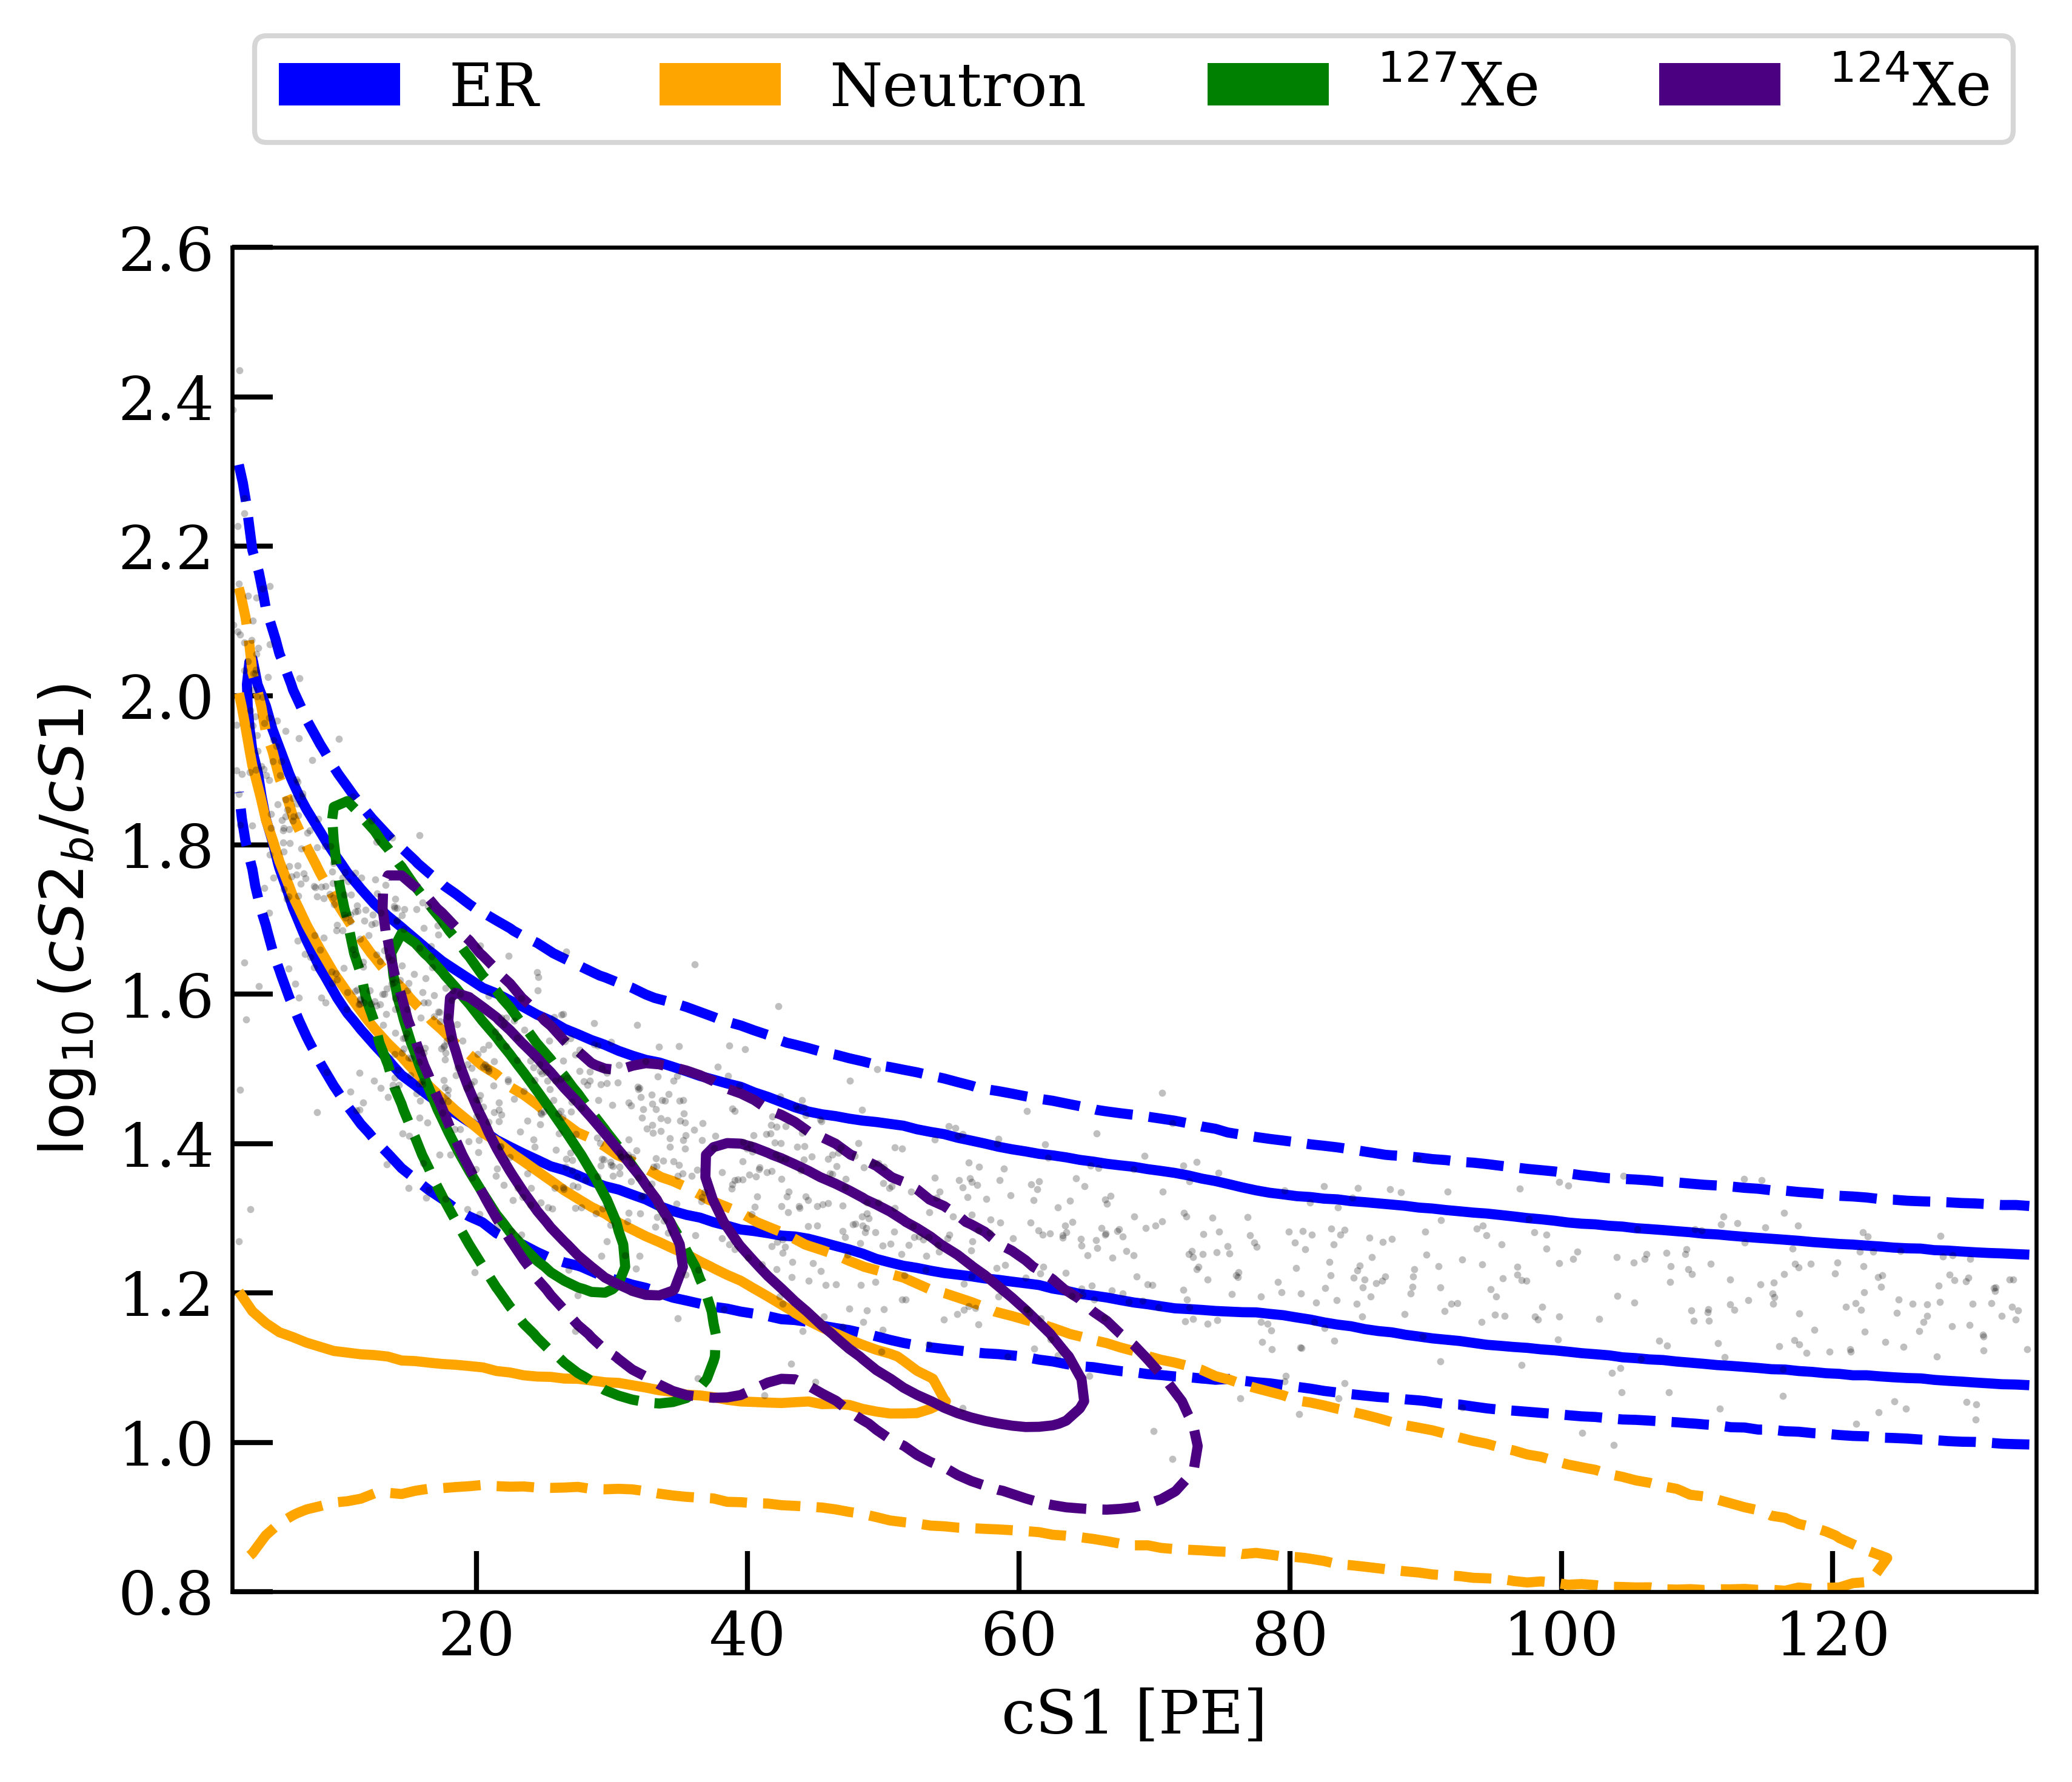

True


True


True


True


True


True


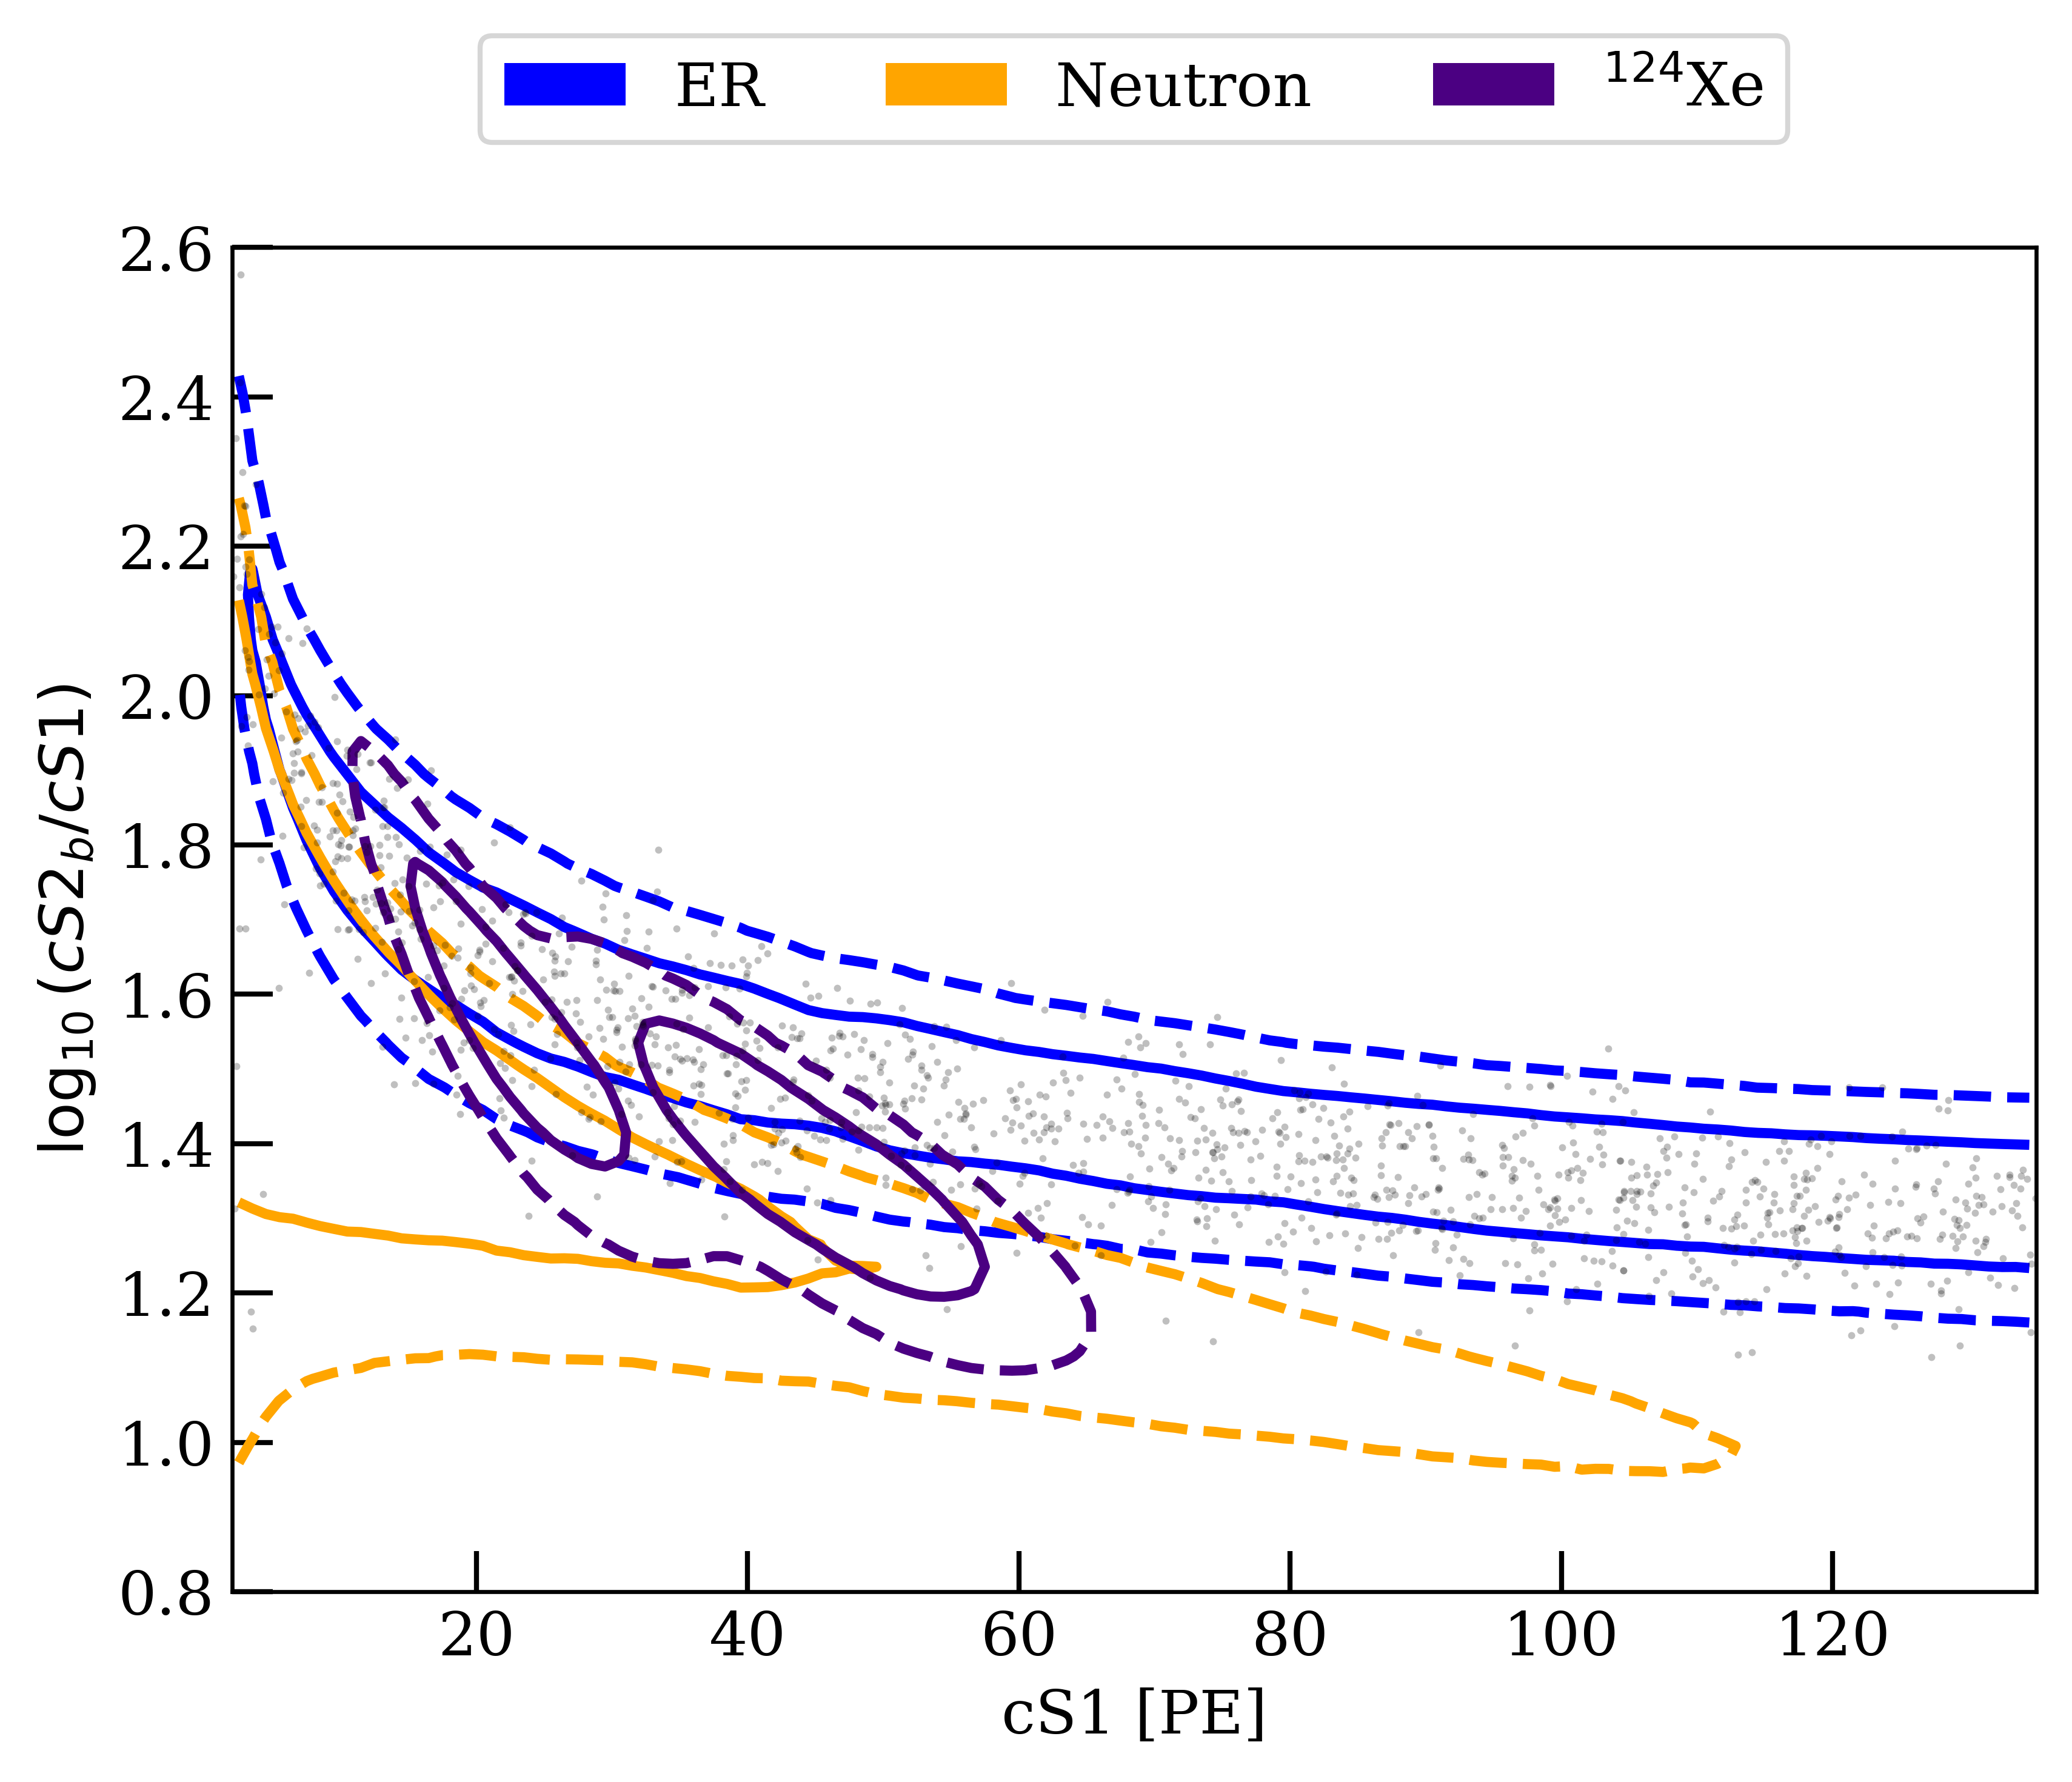

In [9]:
# DEC model: draw the ER (other_er, excl. tritium), neutron, Xe127 and Xe124 best-fit contours
# separately, so the quenched Xe124 DEC (5.98 + 10 keV) and Xe127 (5.2 keV) peaks are
# visible below the ER band. Xe124 uses the best-fit (free) Q_LL/Q_beta; Run1 has no Xe127.
pandax4t_dec_signal_mass = 40
pandax4t_dec_legend_kwargs = {"loc": "upper center", "bbox_to_anchor": (0.5, 1.18), "ncol": 4}
pandax4t_dec_components = {
    "pandax4t_run0": [
        ("ER", ["other_er"], "blue"),
        ("Neutron", ["neutron"], "orange"),
        ("$^{127}$Xe", ["xe127"], "green"),
        ("$^{124}$Xe", ["xe124"], "indigo"),
    ],
    "pandax4t_run1": [
        ("ER", ["other_er"], "blue"),
        ("Neutron", ["neutron"], "orange"),
        ("$^{124}$Xe", ["xe124"], "indigo"),
    ],
}
for experiment_name in ("pandax4t_run0", "pandax4t_run1"):
    run_label = "Run0" if experiment_name.endswith("run0") else "Run1"
    content_specs = [
        {
            "type": "best_fit_bkg",
            "plot_contour_diamx": "contour",
            "plot_contour_literature": False,
            "component_name": label,
            "bkg_to_include": bkgs,
            "color": color,
            "label": label,
        }
        for label, bkgs, color in pandax4t_dec_components[experiment_name]
    ]
    fig, ax = plot_contours_and_pies(
        pandax4t_dec_st,
        {
            "experiment_name": experiment_name,
            "signal_parameter_value": pandax4t_dec_signal_mass,
            "content_specs": content_specs,
            "fig_specs": {
                "figure_size": [6.4, 4.8],
                "axis_names": ["cs1", "logcs2_s1"],
                "axis_labels": ["cS1 [PE]", r"$\log_{10}(cS2_b/cS1)$"],
                "axis_limits": [[2, 135], [0.8, 2.6]],
                "axis_scales": ["linear", "linear"],
                "contour_linestyles": ["--", "-"],
                "plot_pie_charts": False,
                "pie_size_min": 1,
                "pie_size_max": 6,
                "pie_axis_width": 0.01,
                "pie_axis_height": 0.01,
                "legend_kwargs": pandax4t_dec_legend_kwargs,
            },
        },
    )
    # overlay the digitized candidate events (data points)
    for _exp in pandax4t_dec_st.experiment_instances:
        if _exp.experiment_name == experiment_name:
            _data = _exp.get_data()
            break
    ax.scatter(_data["cs1"], _data["logcs2_s1"], s=2, c="black", alpha=0.25, zorder=5, linewidths=0)
    plt.savefig(f"../plots/{experiment_name}_dec_xe_contours.png", dpi=600, bbox_inches="tight")
    plt.show()

In [10]:
# Best-fit Q_LL/Q_beta from the combined PandaX-4T DEC fit (shared between Run0 & Run1).
# The minuit Hesse error is unreliable for a grid-morphed shape parameter (spuriously
# sharp at a template anchor), so we quote the profile-likelihood error from a scan over
# the template grid.
from diamx.model import DiamxModel

_alea = pandax4t_dec_st.update_alea_config_signal(pandax4t_dec_signal_mass)
# widen the limits slightly so the boundary grid anchors are interior during the scan
_alea["parameter_definition"]["ll_quenching_factor"]["fit_limits"] = [0.64, 0.88]
_dec_model = DiamxModel(**_alea)
_dec_model.data = pandax4t_dec_st.get_data(_dec_model, _alea)
_dec_model.fit()
_qll_point = _dec_model.minuit_object.values["ll_quenching_factor"]

_anchors = np.arange(0.65, 0.88, 0.02)
_ll = np.array([_dec_model.fit(ll_quenching_factor=float(v))[1] for v in _anchors])
_t = -2.0 * (_ll - _ll.max())
_fine = np.linspace(_anchors[0], _anchors[-1], 4001)
_tf = np.interp(_fine, _anchors, _t)
_best = _fine[_tf.argmin()]
_below = _fine[_tf <= 1.0]
_err_lo, _err_hi = _best - _below.min(), _below.max() - _best
_err_sym = 0.5 * (_err_lo + _err_hi)

print("PandaX-4T combined Run0+Run1 -- Xe124 DEC fit")
print(f"  best-fit  Q_LL/Q_beta = {_best:.2f}  (+{_err_hi:.2f} / -{_err_lo:.2f})   [profile likelihood]")
print(f"  (minuit point estimate {_qll_point:.3f}; its Hesse error is a template-morphing artifact)")
print(f"  LZ WS2022+WS2024 published: 0.70 +/- 0.04")
print(f"  -> consistent with LZ at {abs(_best - 0.70) / np.hypot(_err_sym, 0.04):.2f} sigma")

True


Computing/loading models on one core:   0%|          | 0/12 [00:00<?, ?it/s]

Computing/loading models on one core: 100%|██████████| 12/12 [00:00<00:00, 891.66it/s]

True


Computing/loading models on one core:   0%|          | 0/12 [00:00<?, ?it/s]

Computing/loading models on one core: 100%|██████████| 12/12 [00:00<00:00, 1041.78it/s]

building data generators:   0%|          | 0/2 [00:00<?, ?it/s]

building data generators: 100%|██████████| 2/2 [00:00<00:00, 112.11it/s]

PandaX-4T combined Run0+Run1 -- Xe124 DEC fit
  best-fit  Q_LL/Q_beta = 0.79  (+0.08 / -0.10)   [profile likelihood]
  (minuit point estimate 0.790; its Hesse error is a template-morphing artifact)
  LZ WS2022+WS2024 published: 0.70 +/- 0.04
  -> consistent with LZ at 0.92 sigma
